In [1]:
import pandas as pd
df = pd.read_csv("data/raw folder/insurance.csv")
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.drop_duplicates(inplace=True)
df.shape
df['smoker'].value_counts()
df.groupby('smoker')['charges'].mean()
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='smoker', y='charges', data=df)

plt.show()
sns.scatterplot(x='bmi', y='charges', data=df)

plt.show()
def bmi_category(bmi):

    if bmi < 18.5:
        return 'Underweight'

    elif bmi < 25:
        return 'Normal'

    elif bmi < 30:
        return 'Overweight'

    else:
        return 'Obese'

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw folder/insurance.csv'

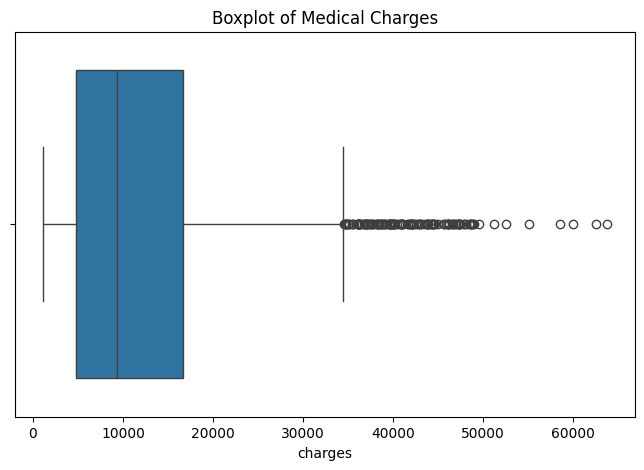

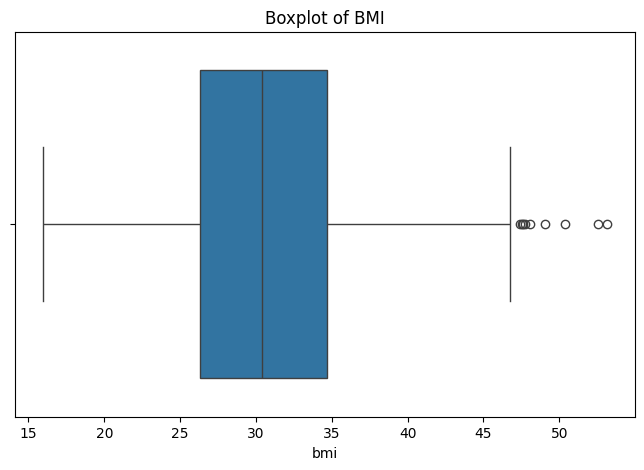

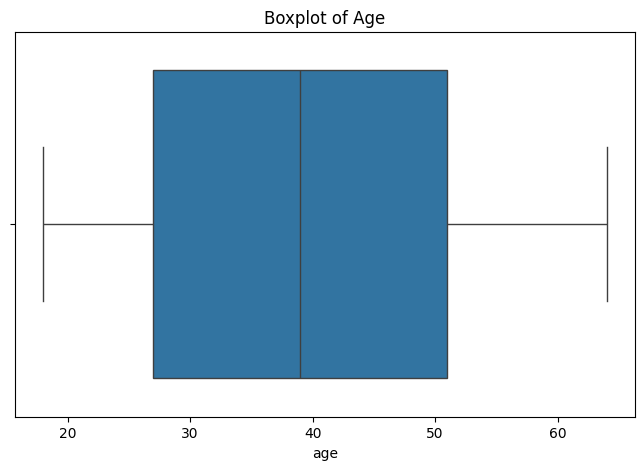

In [ ]:
# BOXPLOT ANALYSIS

import seaborn as sns
import matplotlib.pyplot as plt

# Charges Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Medical Charges")
plt.show()

# BMI Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot of BMI")
plt.show()

# Age Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

In [ ]:
def bmi_category(bmi):

    if bmi < 18.5:
        return 'Underweight'

    elif bmi < 25:
        return 'Normal'

    elif bmi < 30:
        return 'Overweight'

    else:
        return 'Obese'

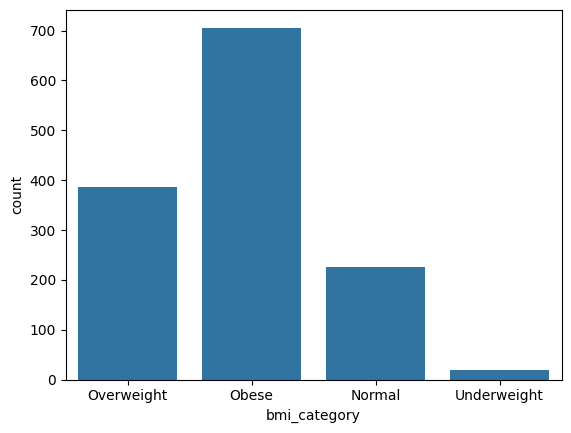

bmi_category
Normal         10409.337709
Obese          15572.041945
Overweight     10987.509891
Underweight     8852.200585
Name: charges, dtype: float64

In [ ]:
df['bmi_category'] = df['bmi'].apply(bmi_category)
df.head()
df['bmi_category'].value_counts()
sns.countplot(x='bmi_category', data=df)

plt.show()
df.groupby('bmi_category')['charges'].mean()


In [ ]:
def risk_score(row):

    score = 0

    if row['smoker'] == 'yes':
        score += 3

    if row['bmi'] >= 30:
        score += 2

    if row['age'] >= 50:
        score += 2

    return score
    
 

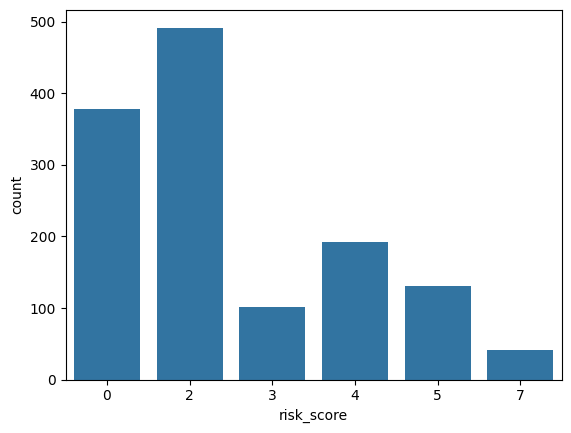

risk_score
0     6252.649268
2     8114.416604
3    20067.304301
4    13557.655509
5    36709.929783
7    46973.114186
Name: charges, dtype: float64

In [ ]:
df['risk_score'] = df.apply(risk_score, axis=1)
df[['age', 'bmi', 'smoker', 'risk_score']].head()
df['risk_score'].value_counts()
sns.countplot(x='risk_score', data=df)
plt.show()
df.groupby('risk_score')['charges'].mean()

In [ ]:
def risk_level(score):

    if score <= 2:
        return 'Low'

    elif score <= 5:
        return 'Medium'

    else:
        return 'High'

In [ ]:
# Checking extreme values in charges column

high_charges = df[df['charges'] > 50000]

high_charges

,age,sex,bmi,children,smoker,region,charges
34,28,male,36.400,1,yes,southwest,51194.55914
543,54,female,47.410,0,yes,southeast,63770.42801
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
1230,52,male,34.485,3,yes,northwest,60021.39897
1300,45,male,30.360,0,yes,southeast,62592.87309


In [ ]:
# Summary statistics of charges

df['charges'].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [ ]:
# Correlation between numerical columns

df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


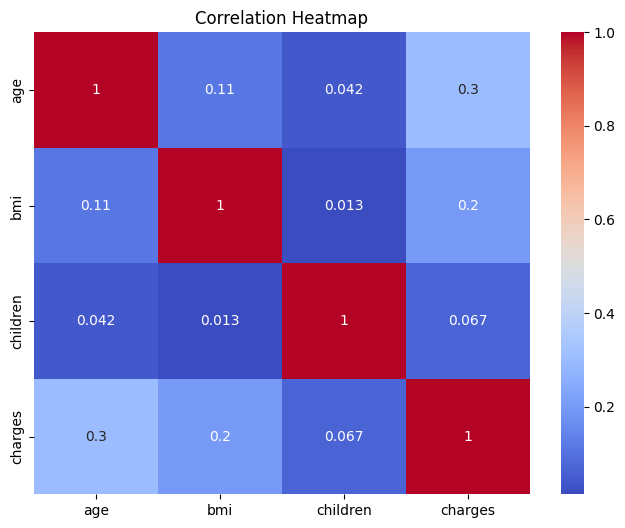

In [ ]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Average charges by smoker status

df.groupby('smoker')['charges'].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

In [ ]:
# Average charges by region

df.groupby('region')['charges'].mean()

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.groupby('bmi_category')['charges'].mean()

bmi_category
Normal         10409.337709
Obese          15572.041945
Overweight     10987.509891
Underweight     8852.200585
Name: charges, dtype: float64

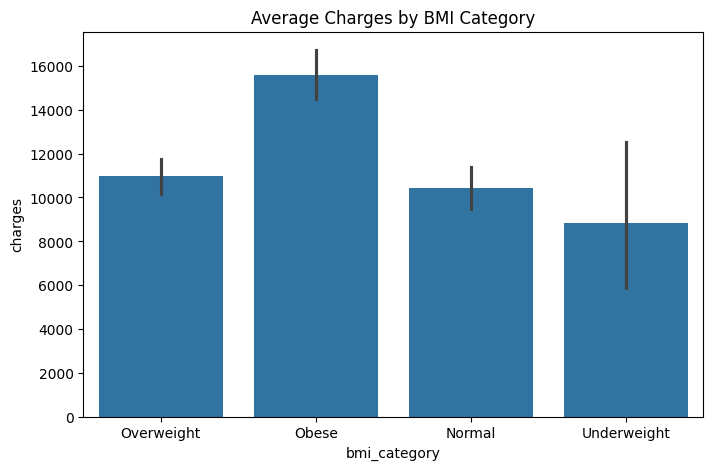

In [ ]:
# Average charges by BMI category graph

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(x='bmi_category',
            y='charges',
            data=df)

plt.title("Average Charges by BMI Category")
plt.show()

In [ ]:
# Risk level distribution

df['risk_level'].value_counts()

risk_level
Low Risk    1337
Name: count, dtype: int64

In [ ]:
df['risk_score'].describe()

count    1337.000000
mean        2.246821
std         1.837025
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max         7.000000
Name: risk_score, dtype: float64

In [ ]:
# Creating risk level column

def risk_level(score):

    if score < 20:
        return 'Low Risk'

    elif score < 40:
        return 'Medium Risk'

    else:
        return 'High Risk'


df['risk_level'] = df['risk_score'].apply(risk_level)

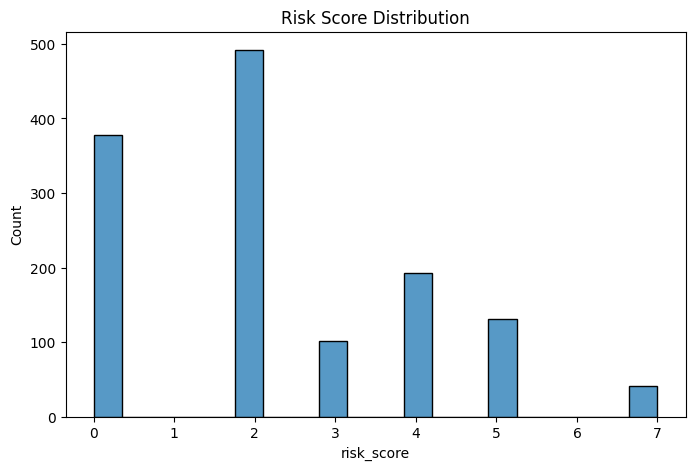

In [ ]:
# Risk score distribution graph

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['risk_score'], bins=20)

plt.title("Risk Score Distribution")
plt.show()

In [ ]:
df['risk_score'].max()

np.int64(7)

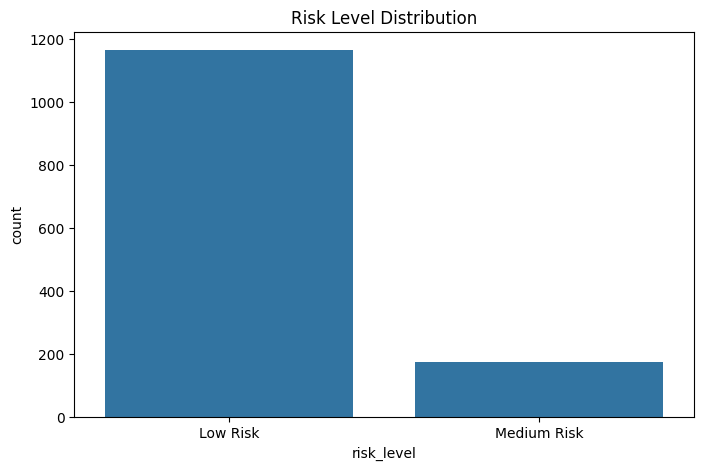

risk_level
Low Risk        9458.615403
Medium Risk    39156.386530
Name: charges, dtype: float64

In [ ]:
# Updated risk level categories

def risk_level(score):

    if score < 5:
        return 'Low Risk'

    elif score < 10:
        return 'Medium Risk'

    else:
        return 'High Risk'


df['risk_level'] = df['risk_score'].apply(risk_level)
df['risk_level'].value_counts()
# Risk level countplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x='risk_level', data=df)

plt.title("Risk Level Distribution")
plt.show()
# Average charges by risk level

df.groupby('risk_level')['charges'].mean()

In [ ]:
# Save cleaned dataset

# Save cleaned dataset

df.to_csv('cleaned_insurance.csv',
          index=False)

In [ ]:
# Check first rows of final dataset

df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,risk_score,risk_level
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,3,Low Risk
1,18,male,33.770,1,no,southeast,1725.55230,Obese,2,Low Risk
2,28,male,33.000,3,no,southeast,4449.46200,Obese,2,Low Risk
3,33,male,22.705,0,no,northwest,21984.47061,Normal,0,Low Risk
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,0,Low Risk


In [ ]:
import shutil

shutil.move(
    'cleaned_insurance.csv',
    '../data/cleaned folder/cleaned_insurance.csv'
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/cleaned folder/cleaned_insurance.csv'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          50 non-null     object
 1   first_name          50 non-null     object
 2   last_name           50 non-null     object
 3   gender              50 non-null     object
 4   date_of_birth       50 non-null     object
 5   contact_number      50 non-null     int64 
 6   address             50 non-null     object
 7   registration_date   50 non-null     object
 8   insurance_provider  50 non-null     object
 9   insurance_number    50 non-null     object
 10  email               50 non-null     object
dtypes: int64(1), object(10)
memory usage: 4.4+ KB


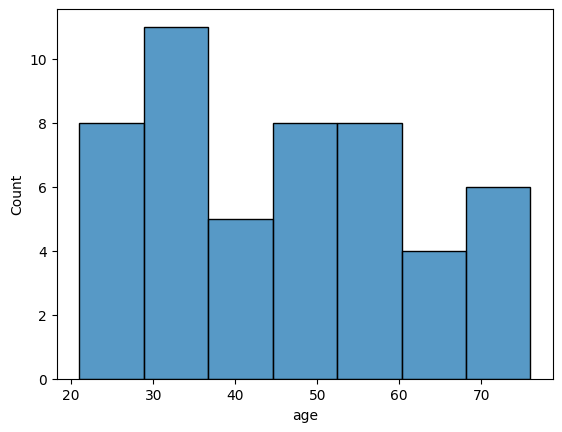

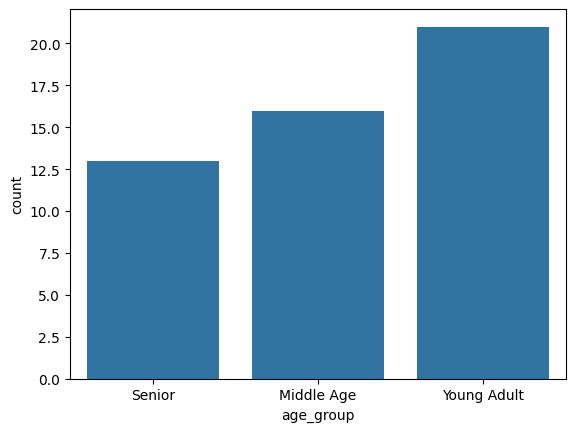

In [ ]:
patients = pd.read_csv("data/raw folder/patients.csv")
patients.head()
patients.info()
patients.shape
patients.isnull().sum()
patients.duplicated().sum()
patients.drop_duplicates(inplace=True)
patients.describe()
patients.head()

patients['date_of_birth'] = pd.to_datetime(patients['date_of_birth'])

patients['registration_date'] = pd.to_datetime(patients['registration_date'])

patients['age'] = 2026 - patients['date_of_birth'].dt.year

patients[['first_name', 'age']].head()

patients['gender'].value_counts()
patients['insurance_provider'].value_counts()

sns.histplot(patients['age'])

plt.show()

def age_group(age):

    if age < 18:
        return 'Child'

    elif age < 40:
        return 'Young Adult'

    elif age < 60:
        return 'Middle Age'

    else:
        return 'Senior'

patients['age_group'] = patients['age'].apply(age_group)   

patients['age_group'].value_counts()

sns.countplot(x='age_group', data=patients)

plt.show()

patients.to_csv("data/cleaned folder/cleaned_patients.csv", index=False)

In [ ]:
treatments = pd.read_csv("data/raw folder/treatments.csv")
treatments.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   treatment_id    200 non-null    object 
 1   appointment_id  200 non-null    object 
 2   treatment_type  200 non-null    object 
 3   description     200 non-null    object 
 4   cost            200 non-null    float64
 5   treatment_date  200 non-null    object 
dtypes: float64(1), object(5)
memory usage: 9.5+ KB


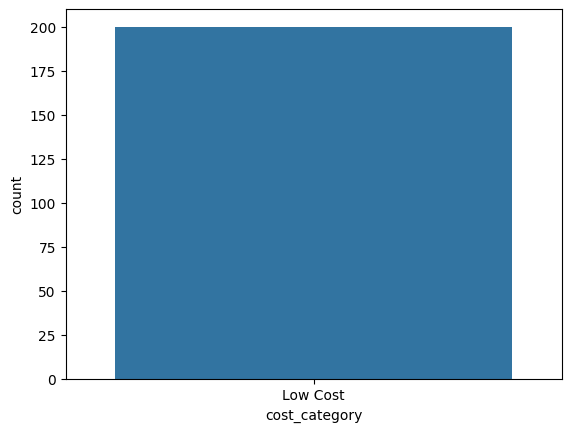

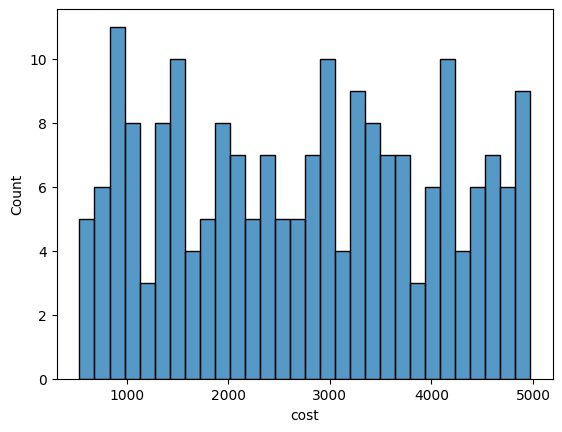

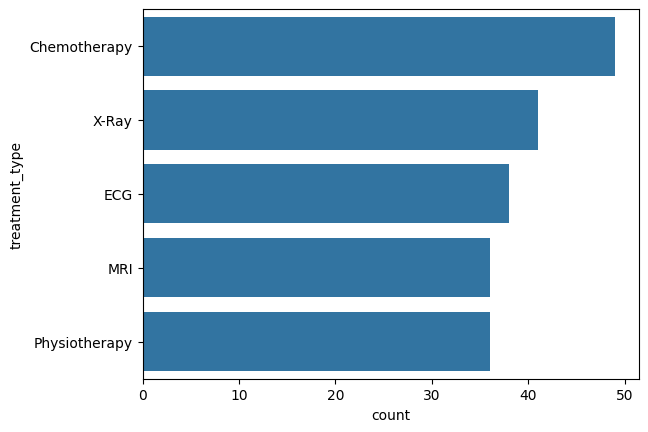

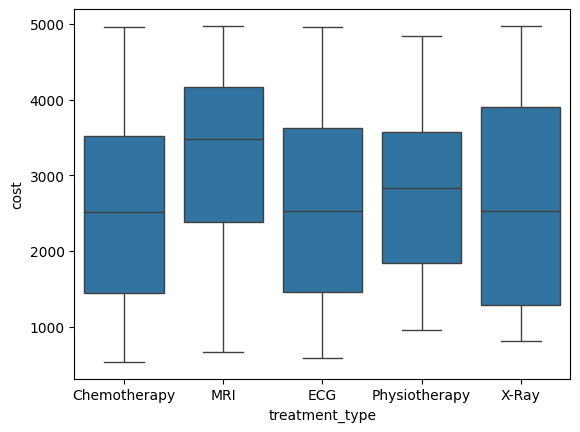

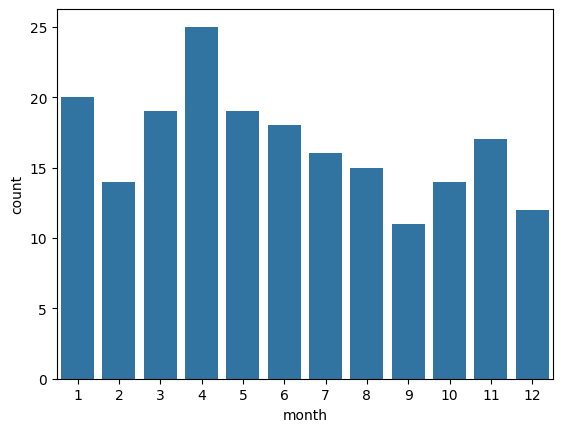

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD TREATMENTS DATASET
# =========================================

treatments = pd.read_csv("data/raw folder/treatments.csv")


# =========================================
# FIRST LOOK
# =========================================

treatments.head()

treatments.info()

treatments.shape


# =========================================
# NULL VALUES CHECK
# =========================================

treatments.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

treatments.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

treatments.drop_duplicates(inplace=True)


# =========================================
# BASIC STATISTICS
# =========================================

treatments.describe()


# =========================================
# CHECK COLUMN NAMES
# =========================================

treatments.columns


# =========================================
# CONVERT DATE COLUMN
# (change column name if needed)
# =========================================

treatments['treatment_date'] = pd.to_datetime(
    treatments['treatment_date']
)


# =========================================
# CREATE TREATMENT COST CATEGORY
# =========================================

def cost_category(cost):

    if cost < 5000:
        return 'Low Cost'

    elif cost < 20000:
        return 'Medium Cost'

    else:
        return 'High Cost'


treatments['cost_category'] = (
    treatments['cost'].apply(cost_category)
)


# =========================================
# CHECK NEW COLUMN
# =========================================

treatments[['cost', 'cost_category']].head()


# =========================================
# COST CATEGORY COUNT
# =========================================

treatments['cost_category'].value_counts()


# =========================================
# GRAPH 1
# COST CATEGORY DISTRIBUTION
# =========================================

sns.countplot(
    x='cost_category',
    data=treatments
)

plt.show()


# =========================================
# GRAPH 2
# TREATMENT COST DISTRIBUTION
# =========================================

sns.histplot(
    treatments['cost'],
    bins=30
)

plt.show()


# =========================================
# GRAPH 3
# TOP TREATMENTS
# =========================================

treatments['treatment_type'].value_counts().head(10)


sns.countplot(
    y='treatment_type',
    data=treatments,
    order=treatments['treatment_type']
    .value_counts()
    .head(10)
    .index
)

plt.show()


# =========================================
# GRAPH 4
# COST VS TREATMENT TYPE
# =========================================

sns.boxplot(
    x='treatment_type',
    y='cost',
    data=treatments
)

plt.show()


# =========================================
# GRAPH 5
# MONTHLY TREATMENT TREND
# =========================================

treatments['month'] = (
    treatments['treatment_date'].dt.month
)

sns.countplot(
    x='month',
    data=treatments
)

plt.show()


# =========================================
# AVERAGE COST BY TREATMENT TYPE
# =========================================

treatments.groupby(
    'treatment_type'
)['cost'].mean()


# =========================================
# MOST EXPENSIVE TREATMENTS
# =========================================

treatments.sort_values(
    by='cost',
    ascending=False
).head()


# =========================================
# SAVE CLEANED DATASET
# =========================================

treatments.to_csv(
    "data/cleaned folder/cleaned_treatments.csv",
    index=False
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


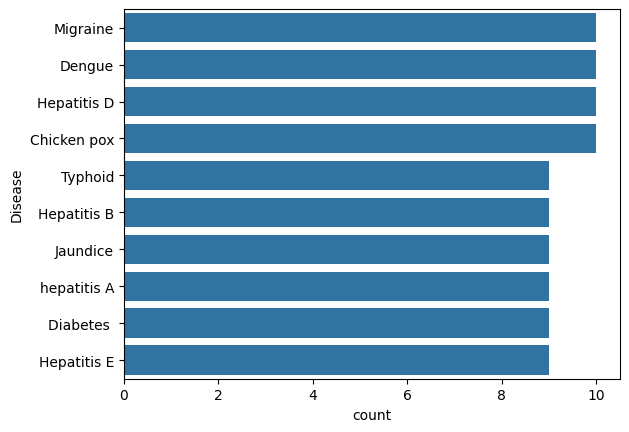

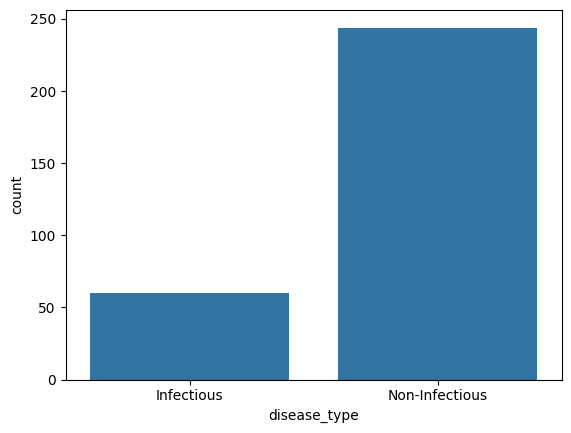

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD DISEASE DATASET
# =========================================

disease = pd.read_csv(
    "data/raw folder/DiseaseAndSymptoms.csv"
)


# =========================================
# FIRST LOOK
# =========================================

disease.head()

disease.info()

disease.shape


# =========================================
# NULL VALUES CHECK
# =========================================

disease.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

disease.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

disease.drop_duplicates(inplace=True)


# =========================================
# COLUMN NAMES
# =========================================

disease.columns


# =========================================
# BASIC STATISTICS
# =========================================

disease.describe()


# =========================================
# CHECK MOST COMMON DISEASES
# =========================================

disease['Disease'].value_counts().head(10)


# =========================================
# TOP 10 DISEASES GRAPH
# =========================================

sns.countplot(
    y='Disease',
    data=disease,
    order=disease['Disease']
    .value_counts()
    .head(10)
    .index
)

plt.show()


# =========================================
# NUMBER OF UNIQUE DISEASES
# =========================================

disease['Disease'].nunique()


# =========================================
# CREATE DISEASE TYPE
# =========================================

infectious = [
    'Fungal infection',
    'Common Cold',
    'Malaria',
    'Typhoid',
    'Tuberculosis',
    'Chicken pox',
    'Dengue'
]


def disease_type(d):

    if d in infectious:
        return 'Infectious'

    else:
        return 'Non-Infectious'


disease['disease_type'] = (
    disease['Disease'].apply(disease_type)
)


# =========================================
# CHECK DISEASE TYPE
# =========================================

disease[['Disease', 'disease_type']].head()


# =========================================
# DISEASE TYPE COUNT
# =========================================

disease['disease_type'].value_counts()


# =========================================
# GRAPH
# INFECTIOUS VS NON-INFECTIOUS
# =========================================

sns.countplot(
    x='disease_type',
    data=disease
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

disease.to_csv(
    "data/cleaned folder/cleaned_disease.csv",
    index=False
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   Country                             1000000 non-null  object 
 1   Year                                1000000 non-null  int64  
 2   Disease Name                        1000000 non-null  object 
 3   Disease Category                    1000000 non-null  object 
 4   Prevalence Rate (%)                 1000000 non-null  float64
 5   Incidence Rate (%)                  1000000 non-null  float64
 6   Mortality Rate (%)                  1000000 non-null  float64
 7   Age Group                           1000000 non-null  object 
 8   Gender                              1000000 non-null  object 
 9   Population Affected                 1000000 non-null  int64  
 10  Healthcare Access (%)               1000000 non-null  float64
 11  Doctors per 

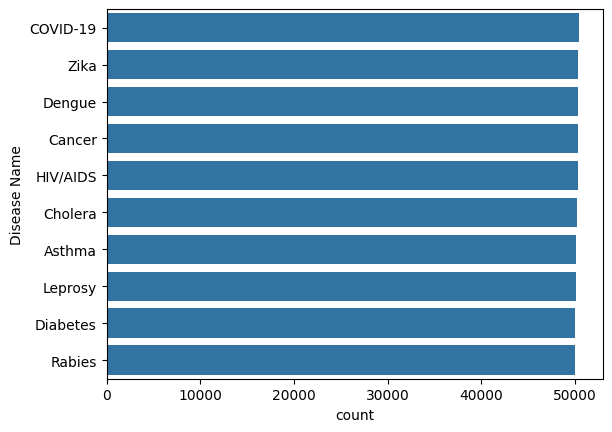

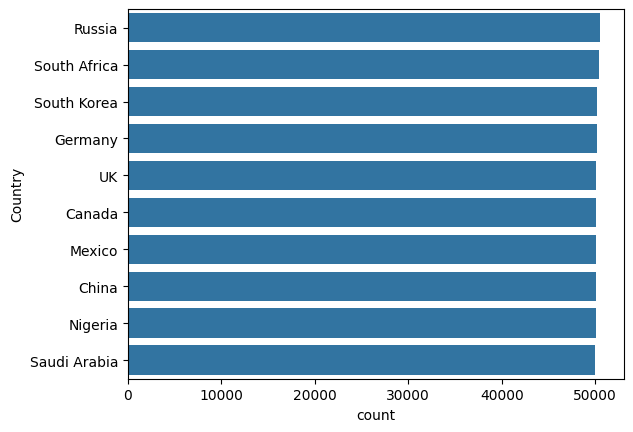

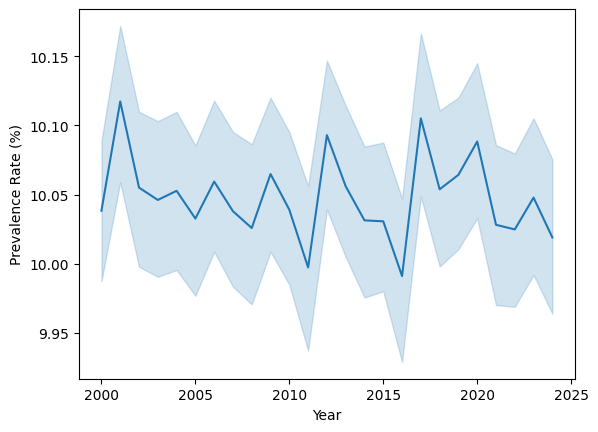

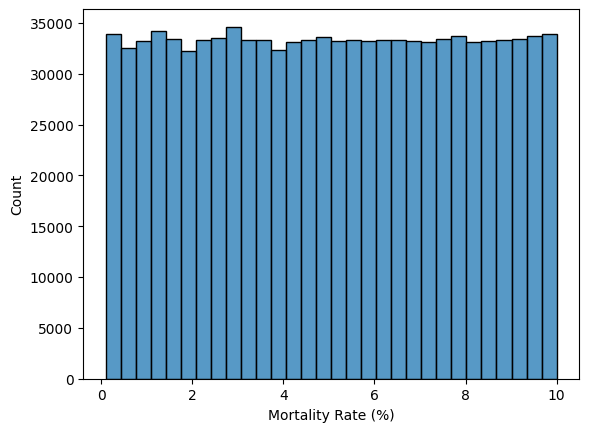

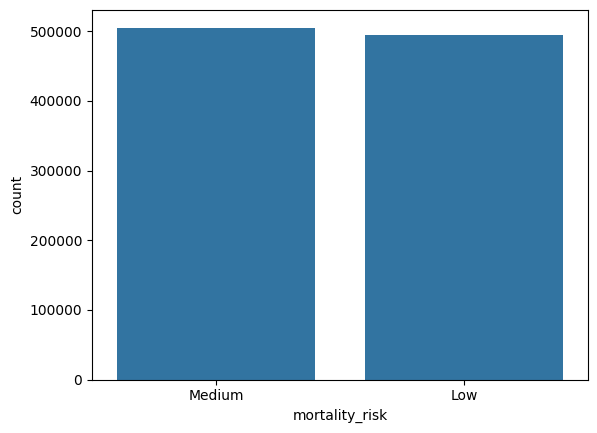

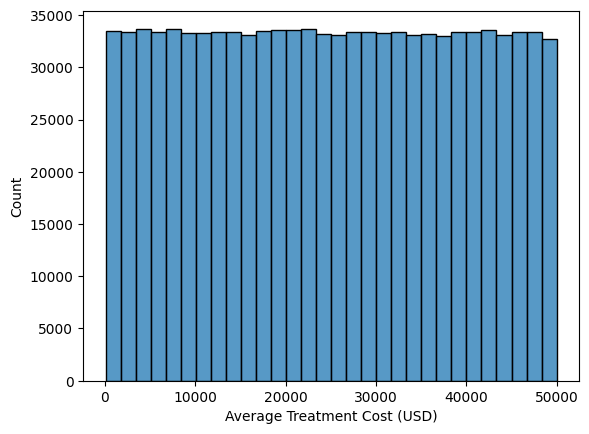

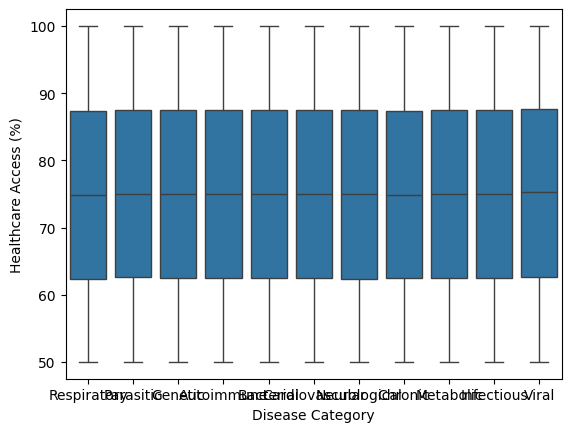

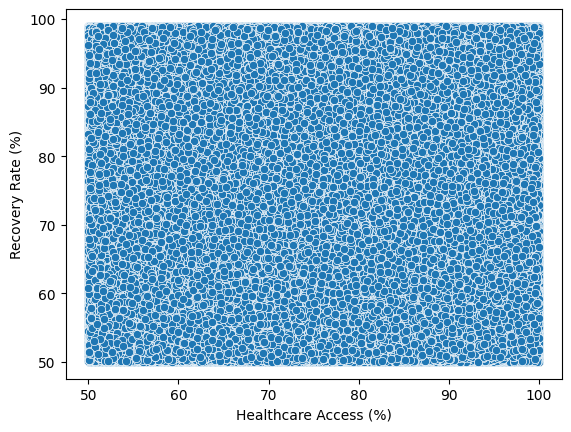

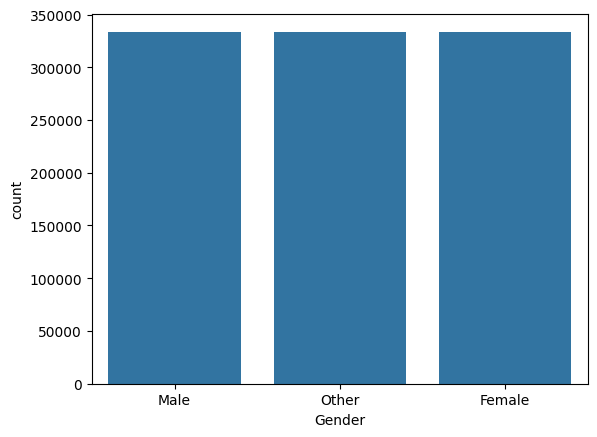

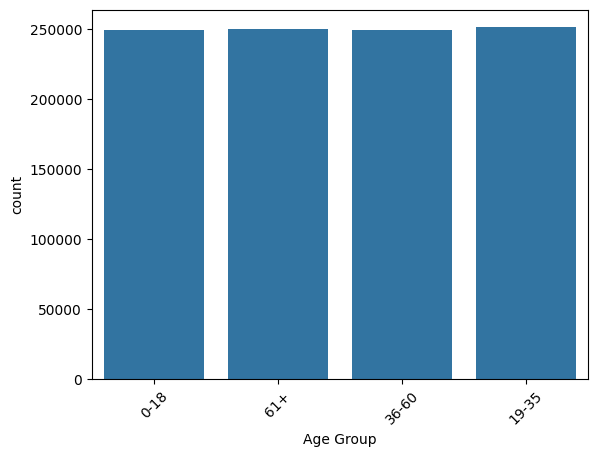

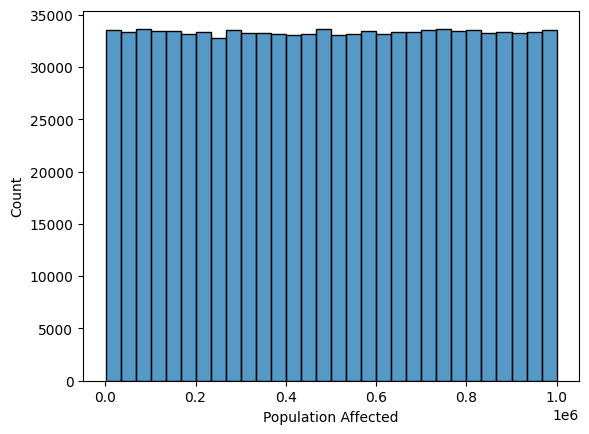

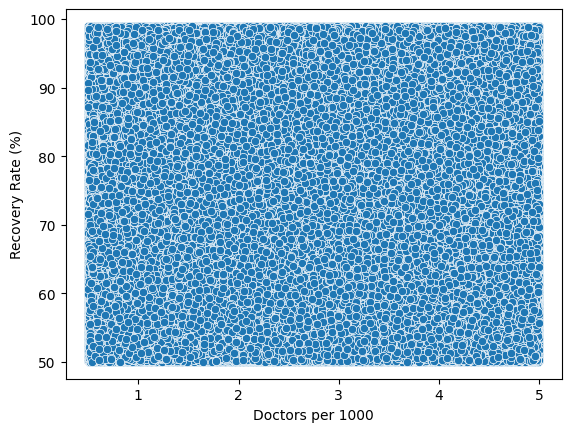

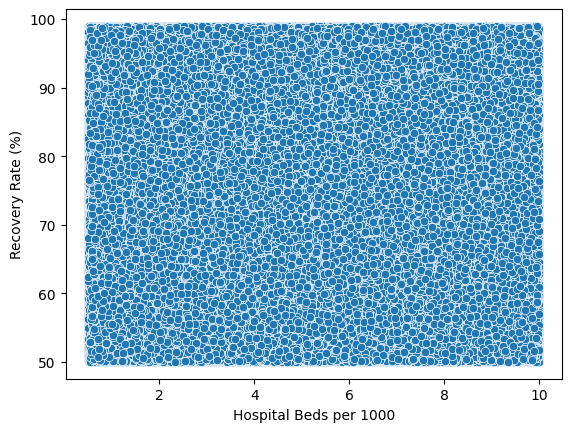

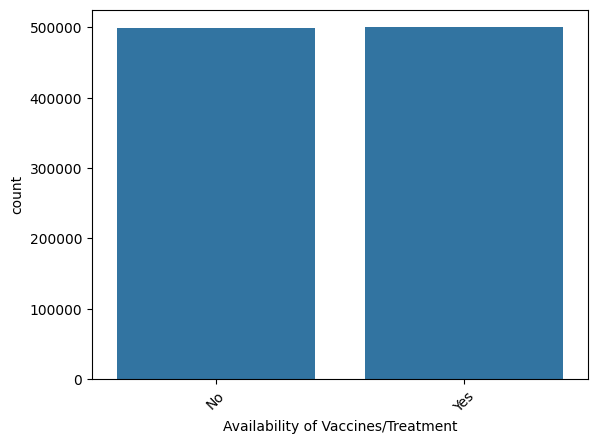

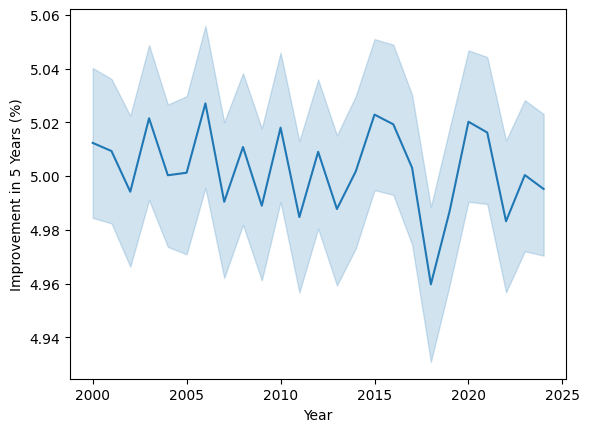

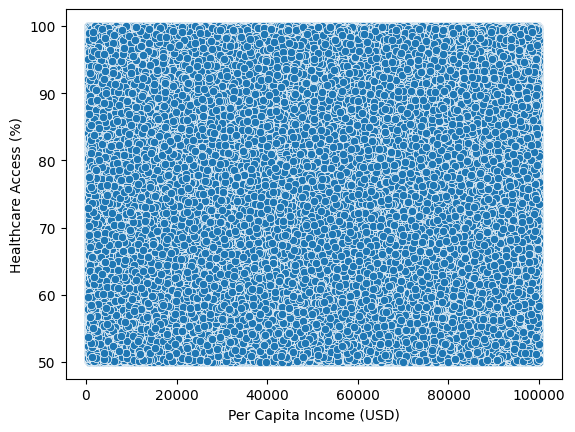

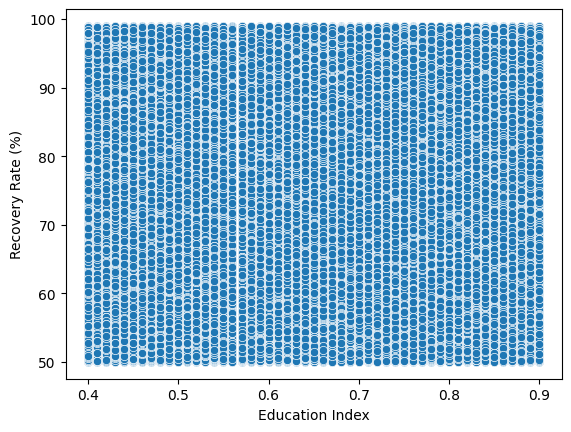

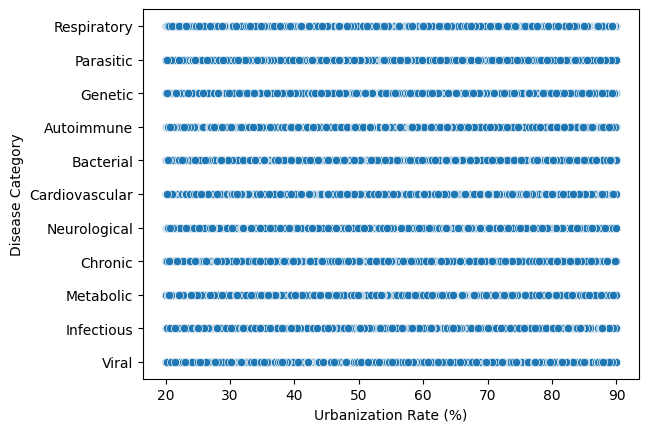

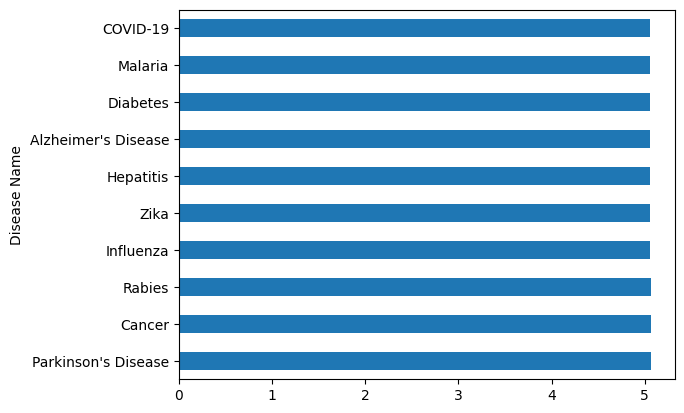

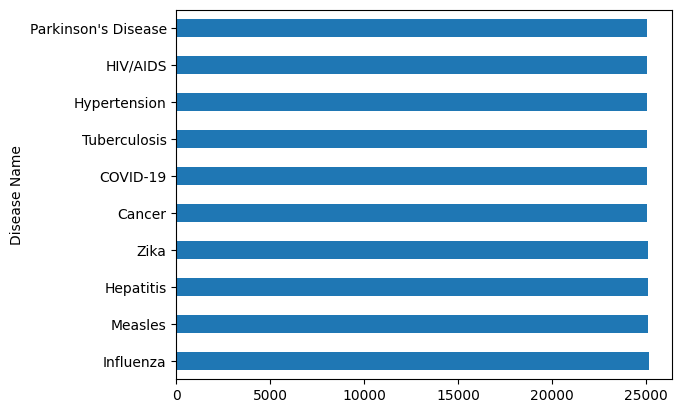

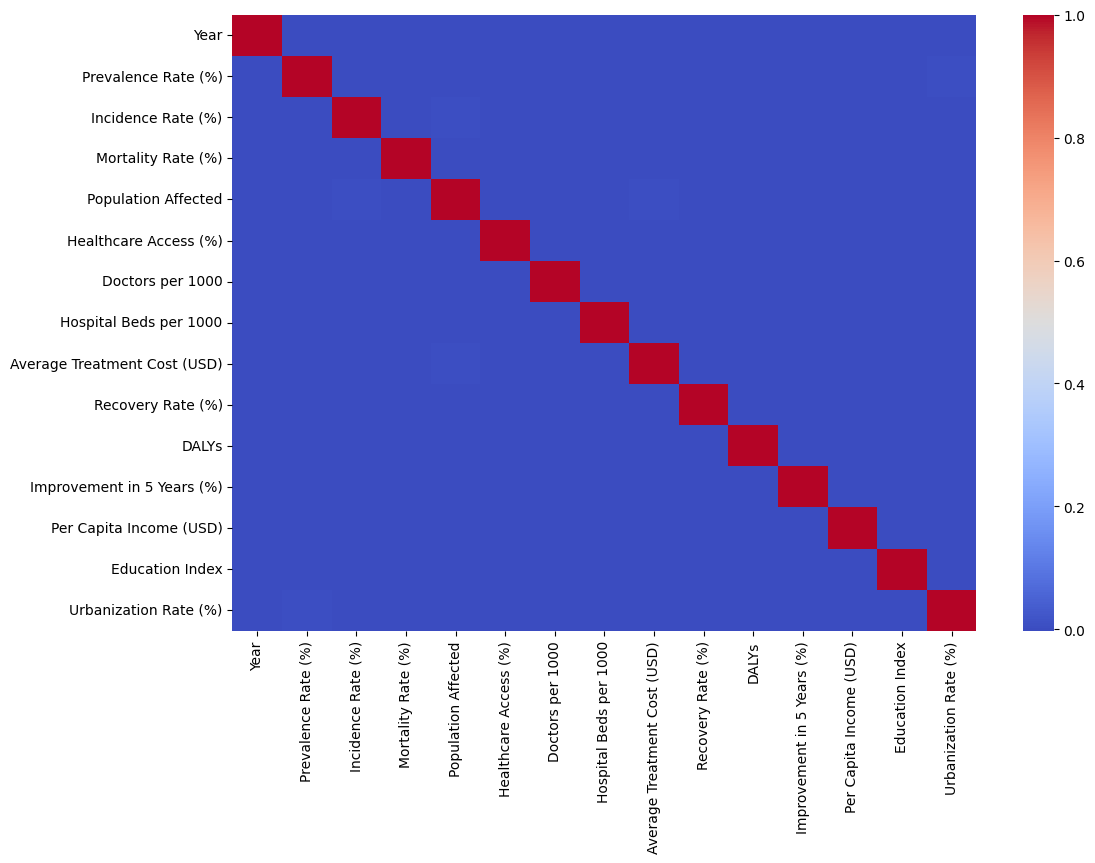

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD GLOBAL HEALTH DATASET
# =========================================

global_health = pd.read_csv(
    "data/raw folder/Global Health Statistics.csv"
)


# =========================================
# FIRST LOOK
# =========================================

global_health.head()

global_health.info()

global_health.shape


# =========================================
# NULL VALUES CHECK
# =========================================

global_health.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

global_health.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

global_health.drop_duplicates(inplace=True)


# =========================================
# CHECK COLUMN NAMES
# =========================================

global_health.columns


# =========================================
# BASIC STATISTICS
# =========================================

global_health.describe()


# =========================================
# TOP DISEASES
# =========================================

global_health['Disease Name'].value_counts().head(10)


# =========================================
# TOP DISEASES GRAPH
# =========================================

sns.countplot(
    y='Disease Name',
    data=global_health,
    order=global_health['Disease Name']
    .value_counts()
    .head(10)
    .index
)

plt.show()


# =========================================
# TOP COUNTRIES
# =========================================

global_health['Country'].value_counts().head(10)


# =========================================
# COUNTRY GRAPH
# =========================================

sns.countplot(
    y='Country',
    data=global_health,
    order=global_health['Country']
    .value_counts()
    .head(10)
    .index
)

plt.show()


# =========================================
# YEARLY DISEASE TREND
# =========================================

sns.lineplot(
    x='Year',
    y='Prevalence Rate (%)',
    data=global_health
)

plt.show()


# =========================================
# MORTALITY ANALYSIS
# =========================================

sns.histplot(
    global_health['Mortality Rate (%)'],
    bins=30
)

plt.show()


# =========================================
# CREATE MORTALITY RISK CATEGORY
# =========================================

def mortality_risk(rate):

    if rate < 5:
        return 'Low'

    elif rate < 15:
        return 'Medium'

    else:
        return 'High'


global_health['mortality_risk'] = (
    global_health['Mortality Rate (%)']
    .apply(mortality_risk)
)


# =========================================
# CHECK NEW COLUMN
# =========================================

global_health[
    ['Mortality Rate (%)', 'mortality_risk']
].head()


# =========================================
# RISK DISTRIBUTION GRAPH
# =========================================

sns.countplot(
    x='mortality_risk',
    data=global_health
)

plt.show()


# =========================================
# MOST DEADLY DISEASES
# =========================================

global_health.groupby(
    'Disease Name'
)['Mortality Rate (%)'].mean().sort_values(
    ascending=False
).head(10)


# =========================================
# AVERAGE TREATMENT COST ANALYSIS
# =========================================

global_health.groupby(
    'Disease Name'
)['Average Treatment Cost (USD)'].mean().sort_values(
    ascending=False
).head(10)


# =========================================
# TREATMENT COST DISTRIBUTION
# =========================================

sns.histplot(
    global_health['Average Treatment Cost (USD)'],
    bins=30
)

plt.show()


# =========================================
# HEALTHCARE ACCESS ANALYSIS
# =========================================

sns.boxplot(
    x='Disease Category',
    y='Healthcare Access (%)',
    data=global_health
)

plt.show()


# =========================================
# RECOVERY RATE ANALYSIS
# =========================================

sns.scatterplot(
    x='Healthcare Access (%)',
    y='Recovery Rate (%)',
    data=global_health
)

plt.show()

# =========================================
# GENDER ANALYSIS
# =========================================

sns.countplot(
    x='Gender',
    data=global_health
)

plt.show()


# =========================================
# AGE GROUP ANALYSIS
# =========================================

sns.countplot(
    x='Age Group',
    data=global_health
)

plt.xticks(rotation=45)

plt.show()


# =========================================
# POPULATION AFFECTED ANALYSIS
# =========================================

sns.histplot(
    global_health['Population Affected'],
    bins=30
)

plt.show()


# =========================================
# DOCTORS PER 1000 ANALYSIS
# =========================================

sns.scatterplot(
    x='Doctors per 1000',
    y='Recovery Rate (%)',
    data=global_health
)

plt.show()


# =========================================
# HOSPITAL BEDS ANALYSIS
# =========================================

sns.scatterplot(
    x='Hospital Beds per 1000',
    y='Recovery Rate (%)',
    data=global_health
)

plt.show()


# =========================================
# VACCINE AVAILABILITY
# =========================================

global_health[
    'Availability of Vaccines/Treatment'
].value_counts()


sns.countplot(
    x='Availability of Vaccines/Treatment',
    data=global_health
)

plt.xticks(rotation=45)

plt.show()


# =========================================
# IMPROVEMENT ANALYSIS
# =========================================

sns.lineplot(
    x='Year',
    y='Improvement in 5 Years (%)',
    data=global_health
)

plt.show()


# =========================================
# INCOME VS HEALTHCARE ACCESS
# =========================================

sns.scatterplot(
    x='Per Capita Income (USD)',
    y='Healthcare Access (%)',
    data=global_health
)

plt.show()


# =========================================
# EDUCATION VS RECOVERY RATE
# =========================================

sns.scatterplot(
    x='Education Index',
    y='Recovery Rate (%)',
    data=global_health
)

plt.show()


# =========================================
# URBANIZATION ANALYSIS
# =========================================

sns.scatterplot(
    x='Urbanization Rate (%)',
    y='Disease Category',
    data=global_health
)

plt.show()

# =========================================
# TOP DEADLY DISEASES GRAPH
# =========================================

top_deadly = global_health.groupby(
    'Disease Name'
)['Mortality Rate (%)'].mean().sort_values(
    ascending=False
).head(10)

top_deadly.plot(
    kind='barh'
)

plt.show()


# =========================================
# TOP EXPENSIVE DISEASES GRAPH
# =========================================

top_expensive = global_health.groupby(
    'Disease Name'
)['Average Treatment Cost (USD)'].mean().sort_values(
    ascending=False
).head(10)

top_expensive.plot(
    kind='barh'
)

plt.show()


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    global_health.corr(numeric_only=True),
    annot=False,
    cmap='coolwarm'
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

global_health.to_csv(
    "data/cleaned folder/cleaned_global_health.csv",
    index=False
)

In [ ]:
global_health.columns

Index(['Country', 'Year', 'Disease Name', 'Disease Category',
       'Prevalence Rate (%)', 'Incidence Rate (%)', 'Mortality Rate (%)',
       'Age Group', 'Gender', 'Population Affected', 'Healthcare Access (%)',
       'Doctors per 1000', 'Hospital Beds per 1000', 'Treatment Type',
       'Average Treatment Cost (USD)', 'Availability of Vaccines/Treatment',
       'Recovery Rate (%)', 'DALYs', 'Improvement in 5 Years (%)',
       'Per Capita Income (USD)', 'Education Index', 'Urbanization Rate (%)'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   7500 non-null   int64  
 1   Age                  7500 non-null   int64  
 2   Gender               7500 non-null   object 
 3   Height_cm            7500 non-null   float64
 4   Weight_kg            7500 non-null   float64
 5   BMI                  7500 non-null   float64
 6   Smoker               7500 non-null   object 
 7   Exercise_Freq        5621 non-null   object 
 8   Diet_Quality         7500 non-null   object 
 9   Alcohol_Consumption  5608 non-null   object 
 10  Chronic_Disease      7500 non-null   object 
 11  Stress_Level         7500 non-null   int64  
 12  Sleep_Hours          7500 non-null   float64
dtypes: float64(4), int64(3), object(6)
memory usage: 761.8+ KB


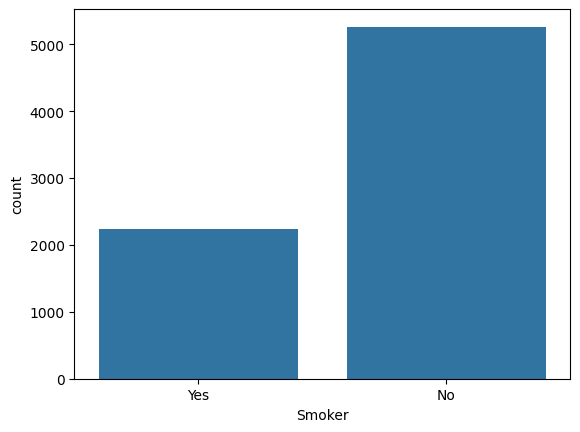

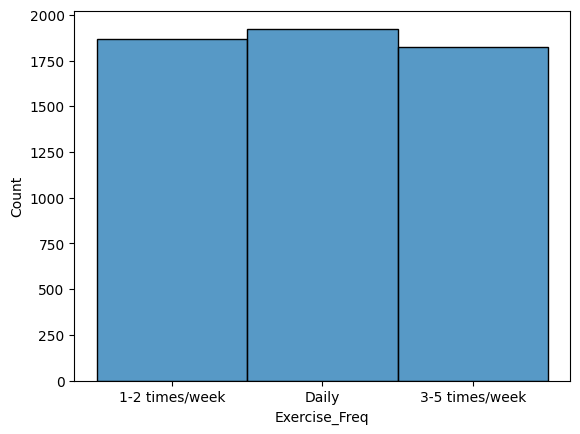

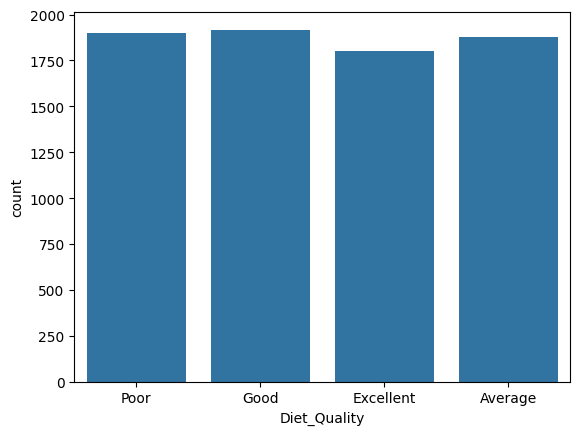

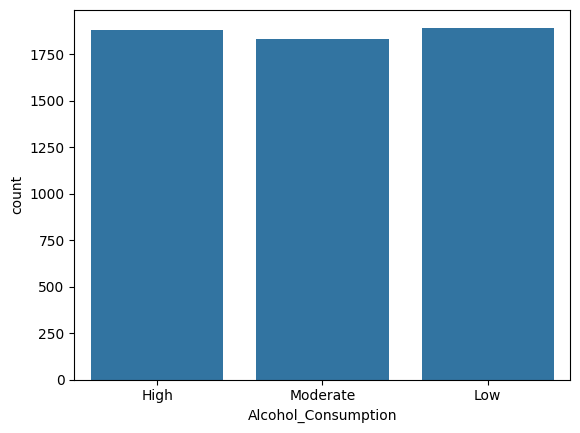

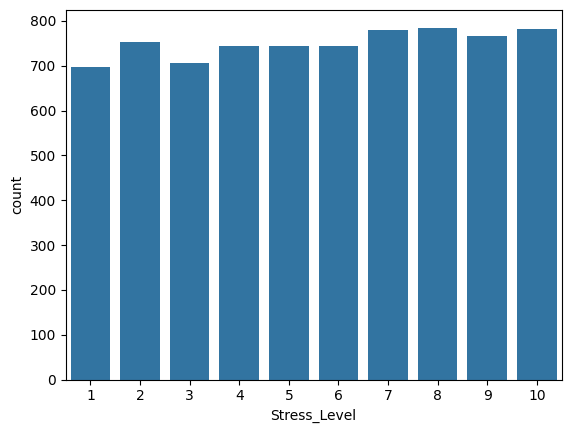

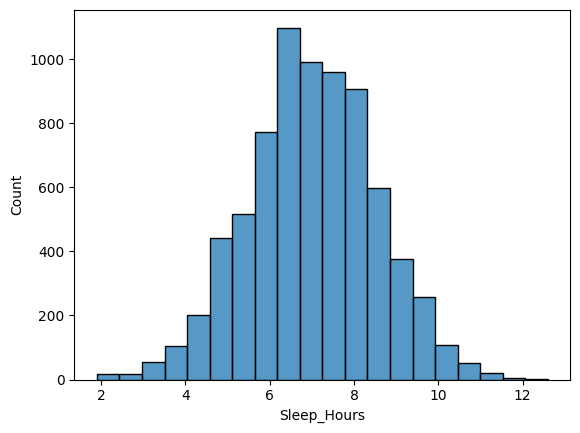

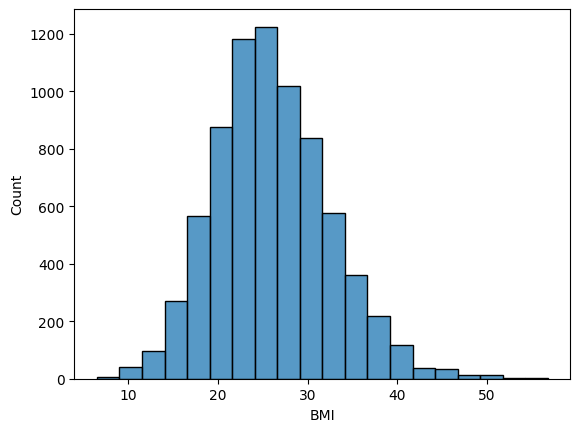

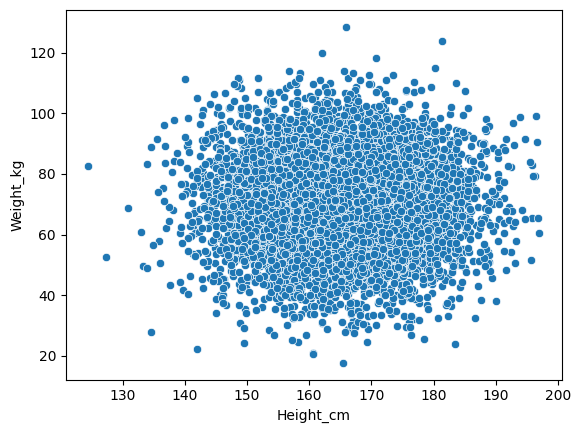

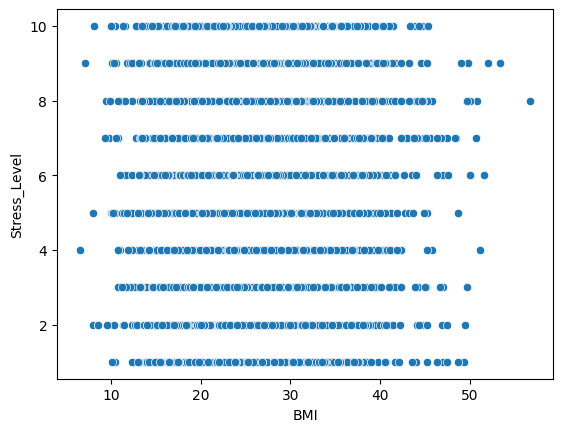

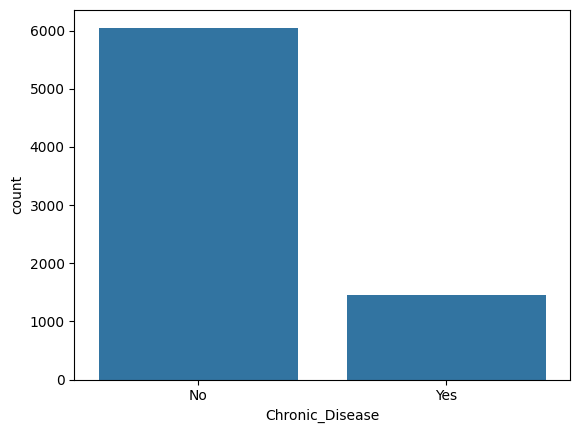

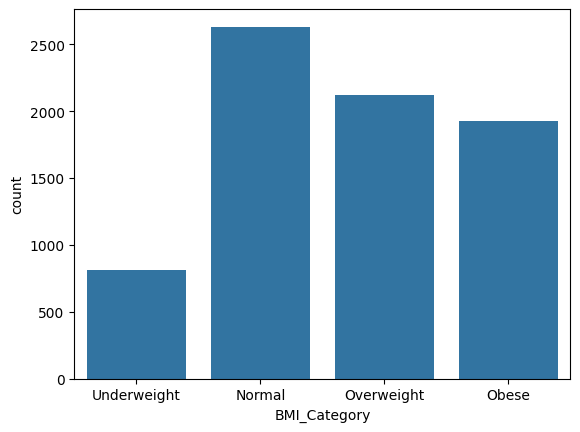

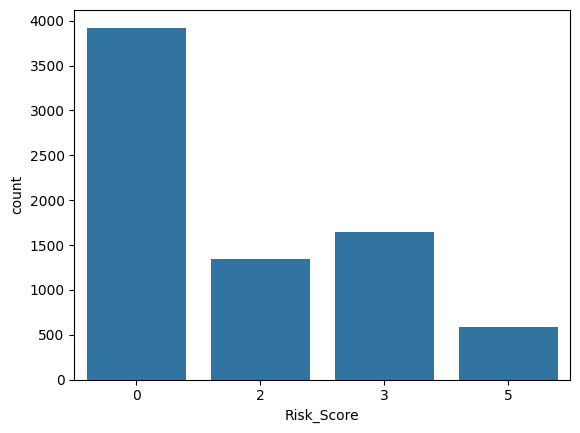

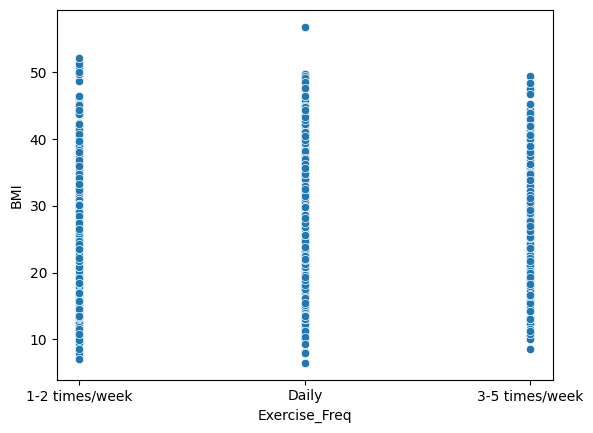

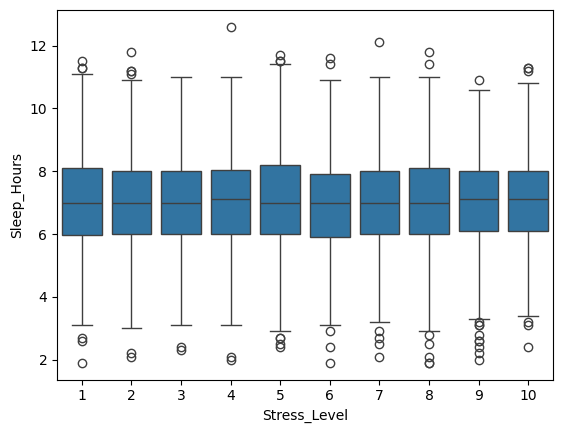

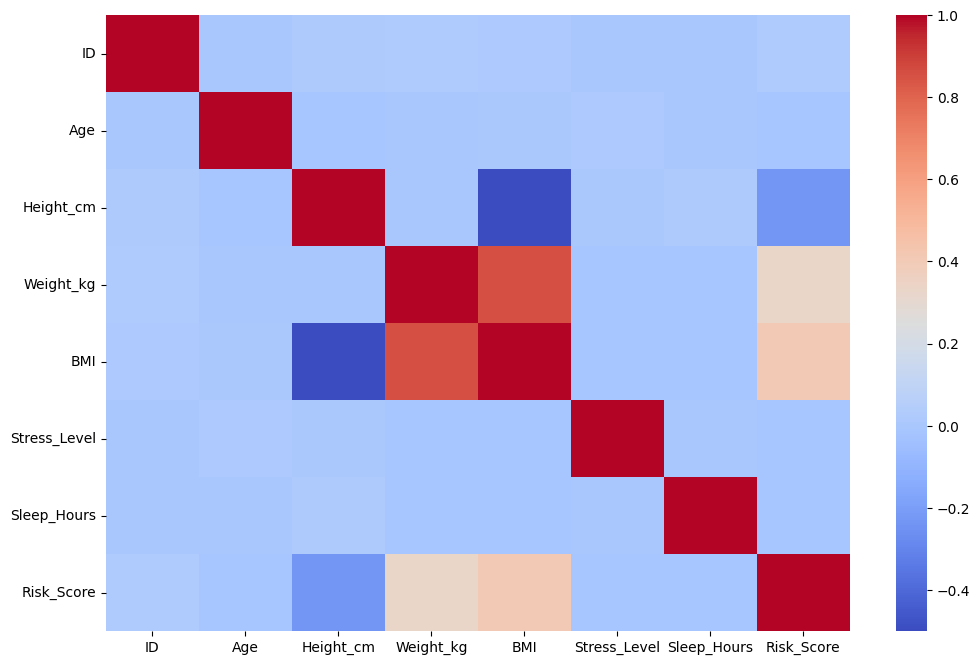

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD LIFESTYLE DATASET
# =========================================

lifestyle = pd.read_csv(
    "data/raw folder/synthetic_health_lifestyle_dataset.csv"
)


# =========================================
# FIRST LOOK
# =========================================

lifestyle.head()

lifestyle.info()

lifestyle.shape


# =========================================
# NULL VALUES CHECK
# =========================================

lifestyle.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

lifestyle.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

lifestyle.drop_duplicates(inplace=True)


# =========================================
# COLUMN NAMES
# =========================================

lifestyle.columns


# =========================================
# BASIC STATISTICS
# =========================================

lifestyle.describe()


# =========================================
# SMOKER ANALYSIS
# =========================================

lifestyle['Smoker'].value_counts()

sns.countplot(
    x='Smoker',
    data=lifestyle
)

plt.show()


# =========================================
# EXERCISE ANALYSIS
# =========================================

sns.histplot(
    lifestyle['Exercise_Freq'],
    bins=20
)

plt.show()


# =========================================
# DIET QUALITY ANALYSIS
# =========================================

sns.countplot(
    x='Diet_Quality',
    data=lifestyle
)

plt.show()


# =========================================
# ALCOHOL ANALYSIS
# =========================================

sns.countplot(
    x='Alcohol_Consumption',
    data=lifestyle
)

plt.show()


# =========================================
# STRESS LEVEL ANALYSIS
# =========================================

sns.countplot(
    x='Stress_Level',
    data=lifestyle
)

plt.show()


# =========================================
# SLEEP ANALYSIS
# =========================================

sns.histplot(
    lifestyle['Sleep_Hours'],
    bins=20
)

plt.show()


# =========================================
# BMI ANALYSIS
# =========================================

sns.histplot(
    lifestyle['BMI'],
    bins=20
)

plt.show()


# =========================================
# HEIGHT VS WEIGHT
# =========================================

sns.scatterplot(
    x='Height_cm',
    y='Weight_kg',
    data=lifestyle
)

plt.show()


# =========================================
# BMI VS STRESS
# =========================================

sns.scatterplot(
    x='BMI',
    y='Stress_Level',
    data=lifestyle
)

plt.show()


# =========================================
# CHRONIC DISEASE ANALYSIS
# =========================================

lifestyle['Chronic_Disease'].value_counts()

sns.countplot(
    x='Chronic_Disease',
    data=lifestyle
)

plt.show()


# =========================================
# BMI CATEGORY FEATURE
# =========================================

def bmi_category(bmi):

    if bmi < 18.5:
        return 'Underweight'

    elif bmi < 25:
        return 'Normal'

    elif bmi < 30:
        return 'Overweight'

    else:
        return 'Obese'


lifestyle['BMI_Category'] = (
    lifestyle['BMI'].apply(bmi_category)
)


# =========================================
# BMI CATEGORY GRAPH
# =========================================

sns.countplot(
    x='BMI_Category',
    data=lifestyle
)

plt.show()


# =========================================
# RISK SCORE FEATURE
# =========================================


def lifestyle_risk(row):

    score = 0

    if row['Smoker'] == 'Yes':
        score += 3

    if row['BMI'] >= 30:
        score += 2

    if row['Stress_Level'] == 'High':
        score += 2

    if row['Exercise_Freq'] == 'Low':
        score += 2

    return score


lifestyle['Risk_Score'] = lifestyle.apply(
    lifestyle_risk,
    axis=1
)
# =========================================
# RISK SCORE ANALYSIS
# =========================================

lifestyle['Risk_Score'].value_counts()

sns.countplot(
    x='Risk_Score',
    data=lifestyle
)

plt.show()


# =========================================
# EXERCISE VS BMI
# =========================================

sns.scatterplot(
    x='Exercise_Freq',
    y='BMI',
    data=lifestyle
)

plt.show()


# =========================================
# SLEEP VS STRESS
# =========================================

sns.boxplot(
    x='Stress_Level',
    y='Sleep_Hours',
    data=lifestyle
)

plt.show()


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    lifestyle.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

lifestyle.to_csv(
    "data/cleaned folder/cleaned_lifestyle.csv",
    index=False
)

In [ ]:
lifestyle.columns

Index(['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Smoker',
       'Exercise_Freq', 'Diet_Quality', 'Alcohol_Consumption',
       'Chronic_Disease', 'Stress_Level', 'Sleep_Hours'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    200 non-null    object
 1   patient_id        200 non-null    object
 2   doctor_id         200 non-null    object
 3   appointment_date  200 non-null    object
 4   appointment_time  200 non-null    object
 5   reason_for_visit  200 non-null    object
 6   status            200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB


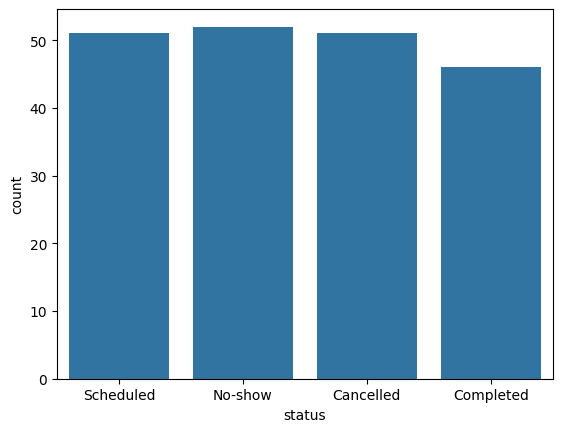

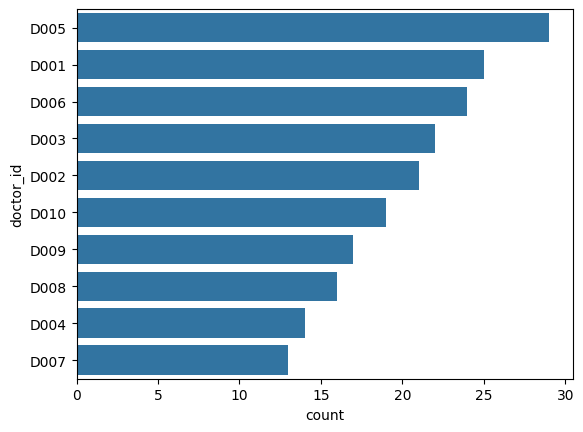

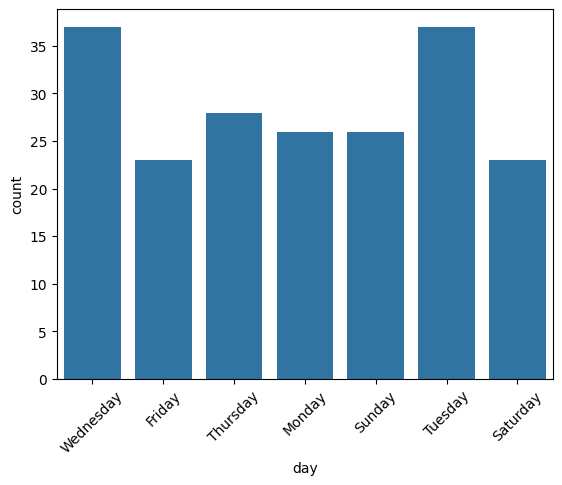

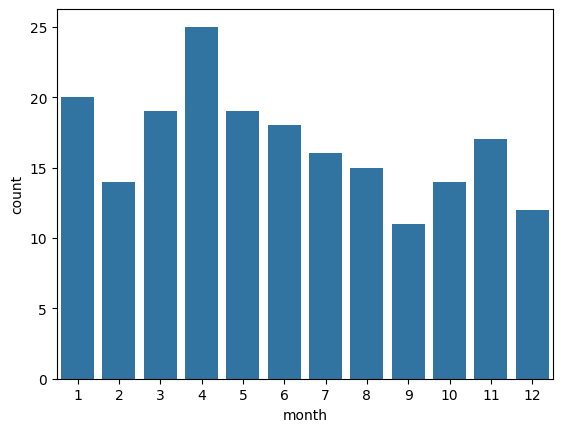

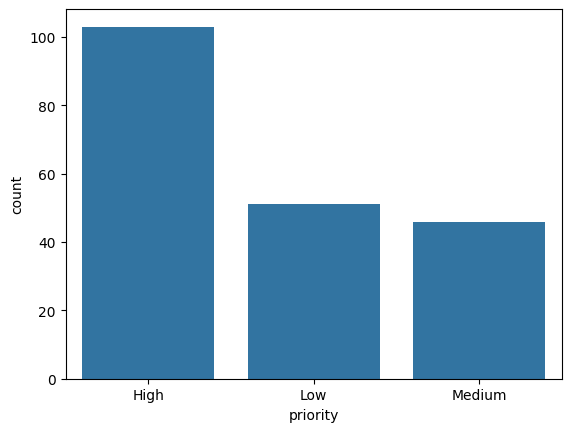

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD APPOINTMENTS DATASET
# =========================================

appointments = pd.read_csv(
    "data/raw folder/appointments.csv"
)


# =========================================
# FIRST LOOK
# =========================================

appointments.head()

appointments.info()

appointments.shape


# =========================================
# NULL VALUES CHECK
# =========================================

appointments.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

appointments.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

appointments.drop_duplicates(inplace=True)


# =========================================
# COLUMN NAMES
# =========================================

appointments.columns


# =========================================
# BASIC STATISTICS
# =========================================

appointments.describe()


# =========================================
# CONVERT DATE COLUMN
# =========================================

appointments['appointment_date'] = pd.to_datetime(
    appointments['appointment_date']
)


# =========================================
# APPOINTMENT STATUS ANALYSIS
# =========================================

appointments['status'].value_counts()

sns.countplot(
    x='status',
    data=appointments
)

plt.show()


# =========================================
# DOCTOR APPOINTMENT LOAD
# =========================================

appointments['doctor_id'].value_counts().head(10)

sns.countplot(
    y='doctor_id',
    data=appointments,
    order=appointments['doctor_id']
    .value_counts()
    .head(10)
    .index
)

plt.show()


# =========================================
# DAILY APPOINTMENT TREND
# =========================================

appointments['day'] = (
    appointments['appointment_date'].dt.day_name()
)

sns.countplot(
    x='day',
    data=appointments
)

plt.xticks(rotation=45)

plt.show()


# =========================================
# MONTHLY TREND
# =========================================

appointments['month'] = (
    appointments['appointment_date'].dt.month
)

sns.countplot(
    x='month',
    data=appointments
)

plt.show()


# =========================================
# APPOINTMENT TIME ANALYSIS
# =========================================

appointments['appointment_time'].value_counts().head(10)


# =========================================
# PATIENT VISIT FREQUENCY
# =========================================

appointments['patient_id'].value_counts().head(10)


# =========================================
# CREATE PRIORITY FEATURE
# =========================================

def appointment_priority(status):

    if status == 'Cancelled':
        return 'Low'

    elif status == 'Completed':
        return 'Medium'

    else:
        return 'High'


appointments['priority'] = (
    appointments['status']
    .apply(appointment_priority)
)


# =========================================
# PRIORITY GRAPH
# =========================================

sns.countplot(
    x='priority',
    data=appointments
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

appointments.to_csv(
    "data/cleaned folder/cleaned_appointments.csv",
    index=False
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   doctor_id         10 non-null     object
 1   first_name        10 non-null     object
 2   last_name         10 non-null     object
 3   specialization    10 non-null     object
 4   phone_number      10 non-null     int64 
 5   years_experience  10 non-null     int64 
 6   hospital_branch   10 non-null     object
 7   email             10 non-null     object
dtypes: int64(2), object(6)
memory usage: 768.0+ bytes


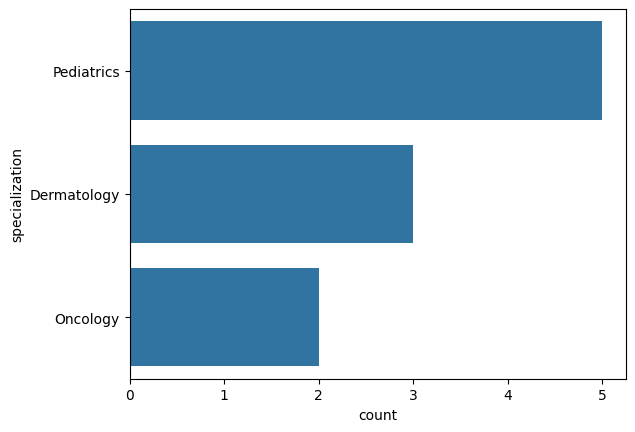

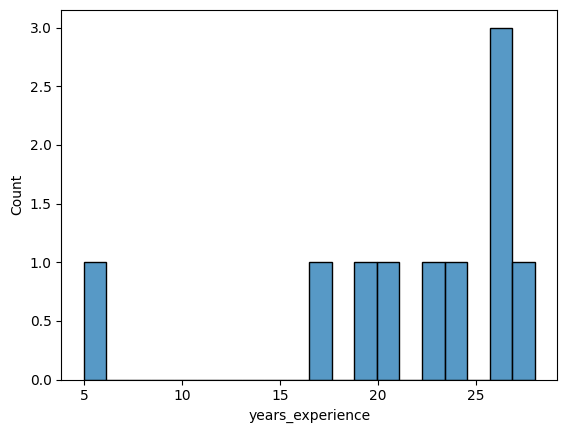

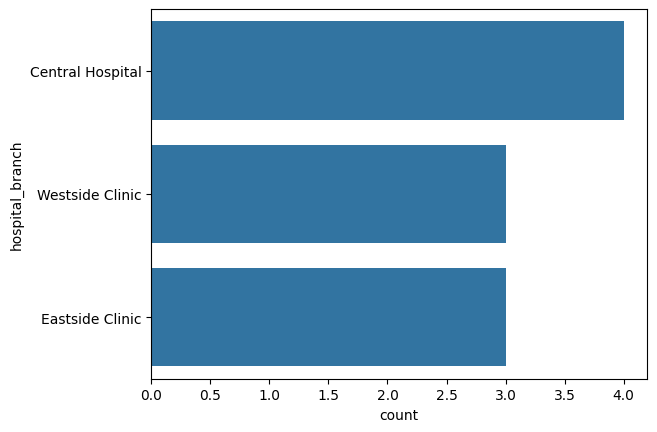

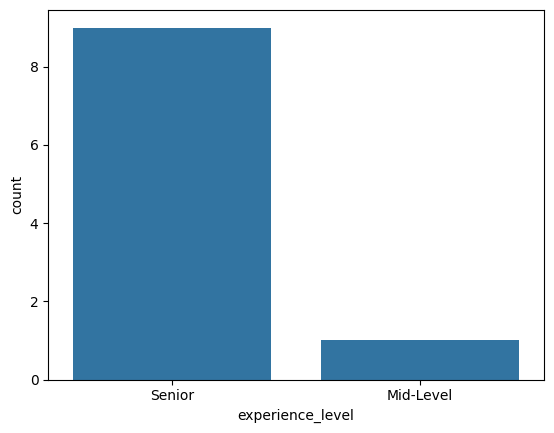

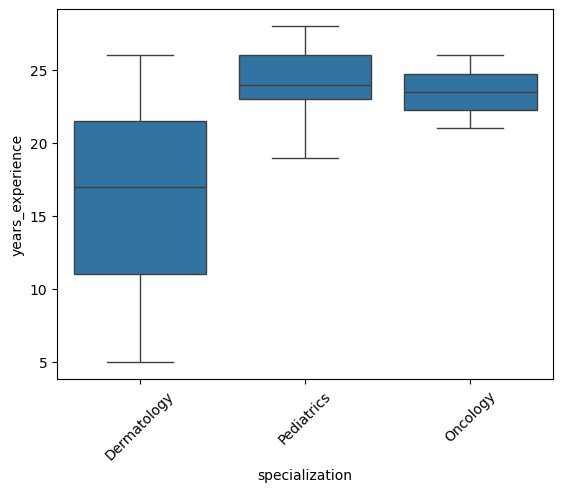

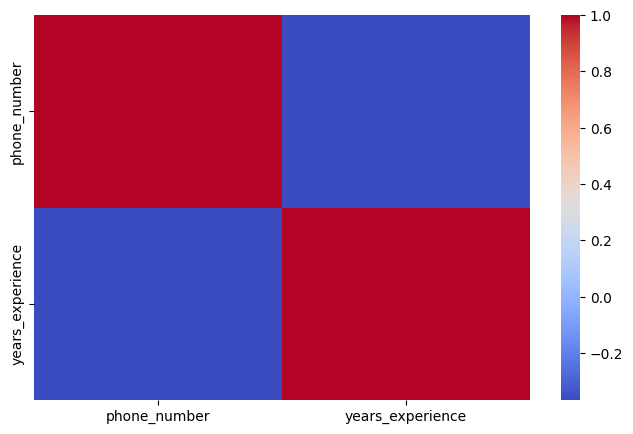

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD DOCTORS DATASET
# =========================================

doctors = pd.read_csv(
    "data/raw folder/doctors.csv"
)


# =========================================
# FIRST LOOK
# =========================================

doctors.head()

doctors.info()

doctors.shape


# =========================================
# NULL VALUES CHECK
# =========================================

doctors.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

doctors.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

doctors.drop_duplicates(inplace=True)


# =========================================
# COLUMN NAMES
# =========================================

doctors.columns


# =========================================
# BASIC STATISTICS
# =========================================

doctors.describe()


# =========================================
# SPECIALIZATION ANALYSIS
# =========================================

doctors['specialization'].value_counts()

sns.countplot(
    y='specialization',
    data=doctors,
    order=doctors['specialization']
    .value_counts()
    .index
)

plt.show()


# =========================================
# EXPERIENCE ANALYSIS
# =========================================

sns.histplot(
    doctors['years_experience'],
    bins=20
)

plt.show()


# =========================================
# HOSPITAL BRANCH ANALYSIS
# =========================================

doctors['hospital_branch'].value_counts()

sns.countplot(
    y='hospital_branch',
    data=doctors,
    order=doctors['hospital_branch']
    .value_counts()
    .index
)

plt.show()


# =========================================
# TOP EXPERIENCED DOCTORS
# =========================================

doctors.sort_values(
    by='years_experience',
    ascending=False
).head(10)


# =========================================
# EXPERIENCE CATEGORY FEATURE
# =========================================

def experience_level(exp):

    if exp < 5:
        return 'Junior'

    elif exp < 15:
        return 'Mid-Level'

    else:
        return 'Senior'


doctors['experience_level'] = (
    doctors['years_experience']
    .apply(experience_level)
)


# =========================================
# EXPERIENCE LEVEL GRAPH
# =========================================

sns.countplot(
    x='experience_level',
    data=doctors
)

plt.show()


# =========================================
# SPECIALIZATION VS EXPERIENCE
# =========================================

sns.boxplot(
    x='specialization',
    y='years_experience',
    data=doctors
)

plt.xticks(rotation=45)

plt.show()


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(8,5))

sns.heatmap(
    doctors.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

doctors.to_csv(
    "data/cleaned folder/cleaned_doctors.csv",
    index=False
)

In [ ]:
doctors.columns

Index(['doctor_id', 'first_name', 'last_name', 'specialization',
       'phone_number', 'years_experience', 'hospital_branch', 'email'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bill_id         200 non-null    object 
 1   patient_id      200 non-null    object 
 2   treatment_id    200 non-null    object 
 3   bill_date       200 non-null    object 
 4   amount          200 non-null    float64
 5   payment_method  200 non-null    object 
 6   payment_status  200 non-null    object 
dtypes: float64(1), object(6)
memory usage: 11.1+ KB


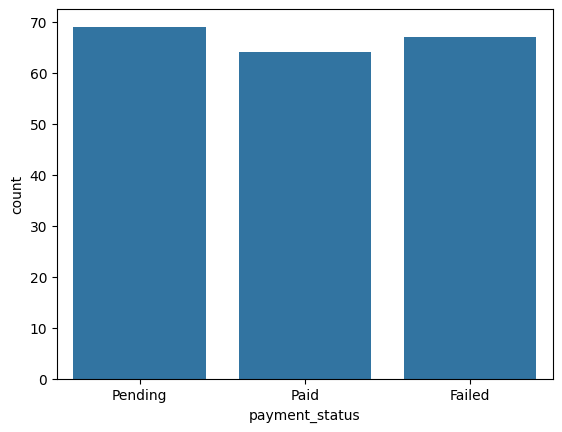

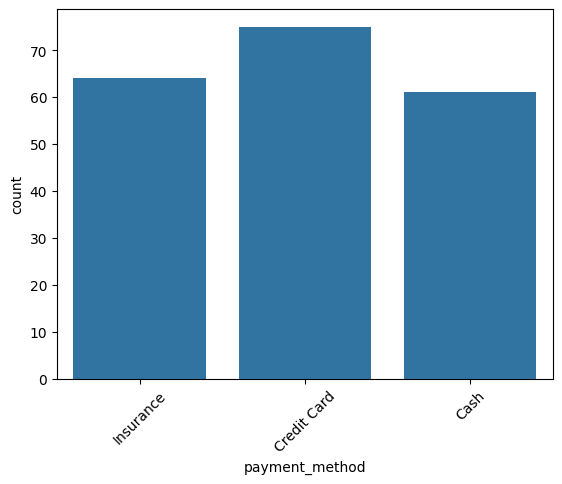

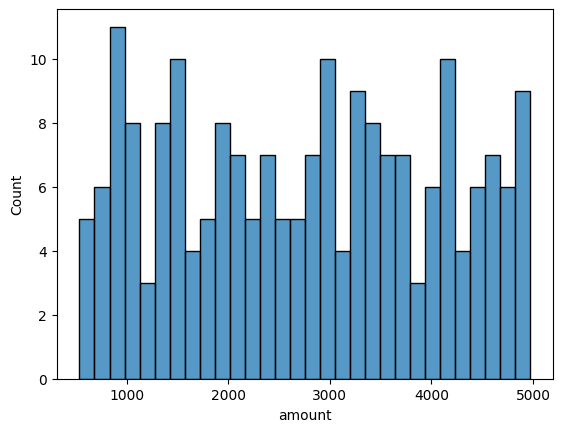

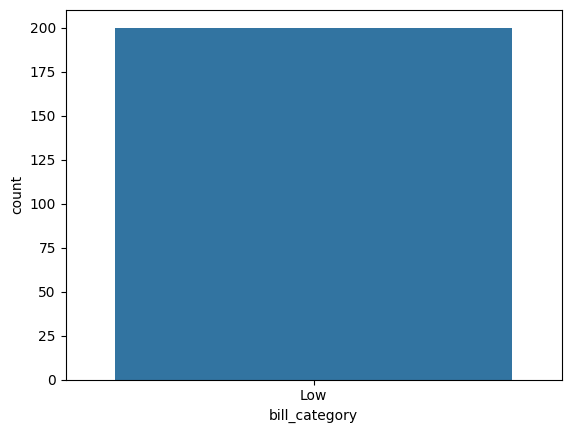

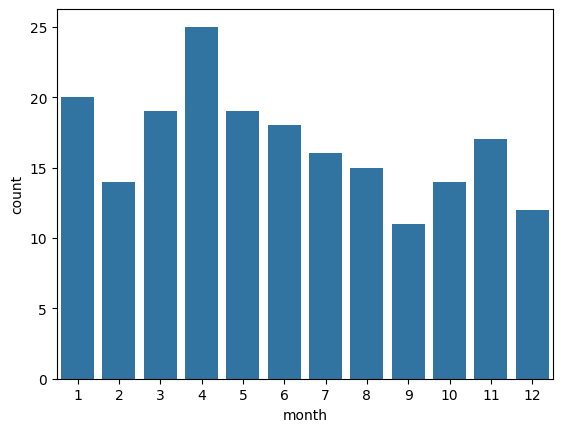

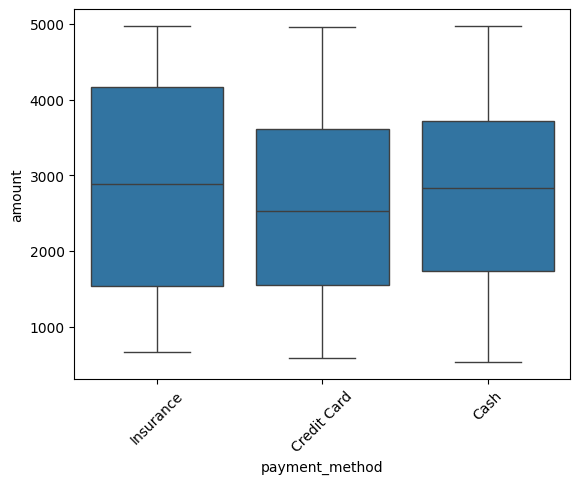

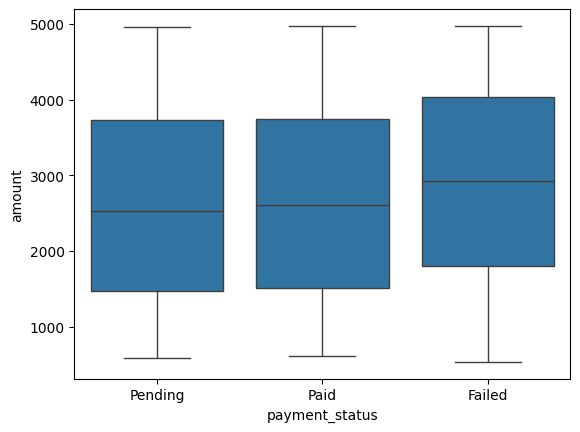

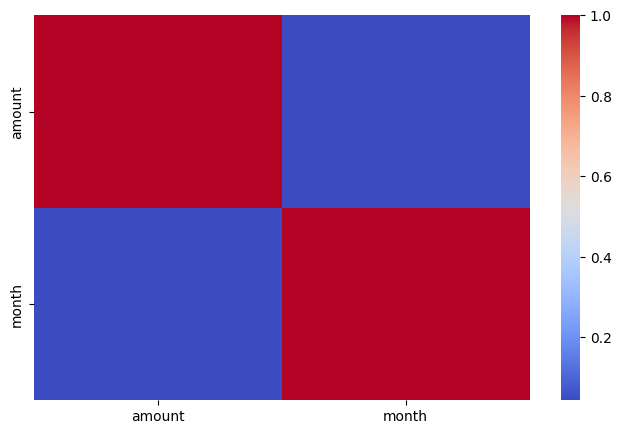

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD BILLING DATASET
# =========================================

billing = pd.read_csv(
    "data/raw folder/billing.csv"
)


# =========================================
# FIRST LOOK
# =========================================

billing.head()

billing.info()

billing.shape


# =========================================
# NULL VALUES CHECK
# =========================================

billing.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

billing.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

billing.drop_duplicates(inplace=True)


# =========================================
# COLUMN NAMES
# =========================================

billing.columns


# =========================================
# BASIC STATISTICS
# =========================================

billing.describe()


# =========================================
# CONVERT DATE COLUMN
# =========================================

billing['bill_date'] = pd.to_datetime(
    billing['bill_date']
)


# =========================================
# PAYMENT STATUS ANALYSIS
# =========================================

billing['payment_status'].value_counts()

sns.countplot(
    x='payment_status',
    data=billing
)

plt.show()


# =========================================
# PAYMENT METHOD ANALYSIS
# =========================================

billing['payment_method'].value_counts()

sns.countplot(
    x='payment_method',
    data=billing
)

plt.xticks(rotation=45)

plt.show()


# =========================================
# BILL AMOUNT DISTRIBUTION
# =========================================

sns.histplot(
    billing['amount'],
    bins=30
)

plt.show()


# =========================================
# HIGH VALUE BILLS
# =========================================

billing.sort_values(
    by='amount',
    ascending=False
).head(10)


# =========================================
# BILL CATEGORY FEATURE
# =========================================

def bill_category(amount):

    if amount < 5000:
        return 'Low'

    elif amount < 20000:
        return 'Medium'

    else:
        return 'High'


billing['bill_category'] = (
    billing['amount']
    .apply(bill_category)
)


# =========================================
# BILL CATEGORY GRAPH
# =========================================

sns.countplot(
    x='bill_category',
    data=billing
)

plt.show()


# =========================================
# MONTHLY BILLING TREND
# =========================================

billing['month'] = (
    billing['bill_date'].dt.month
)

sns.countplot(
    x='month',
    data=billing
)

plt.show()


# =========================================
# PAYMENT METHOD VS AMOUNT
# =========================================

sns.boxplot(
    x='payment_method',
    y='amount',
    data=billing
)

plt.xticks(rotation=45)

plt.show()


# =========================================
# PAYMENT STATUS VS AMOUNT
# =========================================

sns.boxplot(
    x='payment_status',
    y='amount',
    data=billing
)

plt.show()


# =========================================
# TOTAL REVENUE
# =========================================

billing['amount'].sum()


# =========================================
# REVENUE BY PAYMENT METHOD
# =========================================

billing.groupby(
    'payment_method'
)['amount'].sum()


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(8,5))

sns.heatmap(
    billing.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

billing.to_csv(
    "data/cleaned folder/cleaned_billing.csv",
    index=False
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


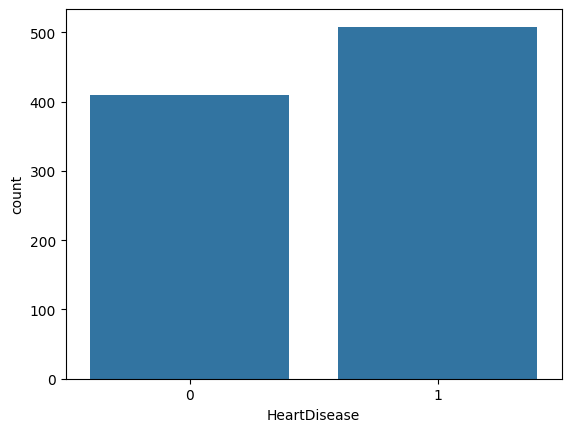

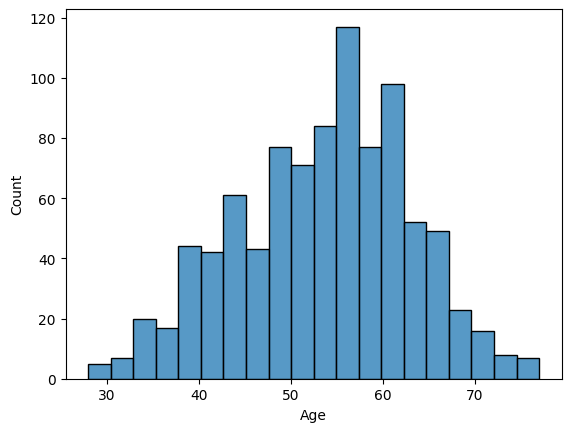

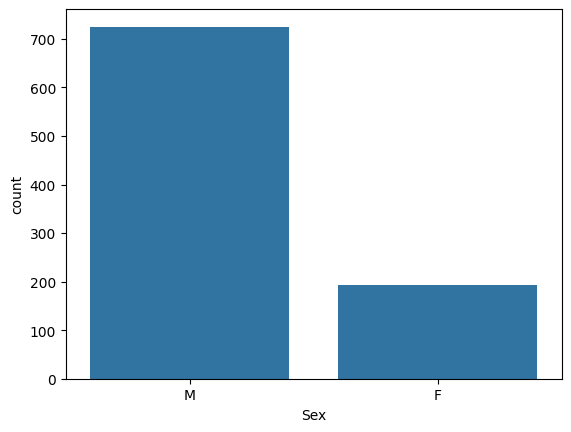

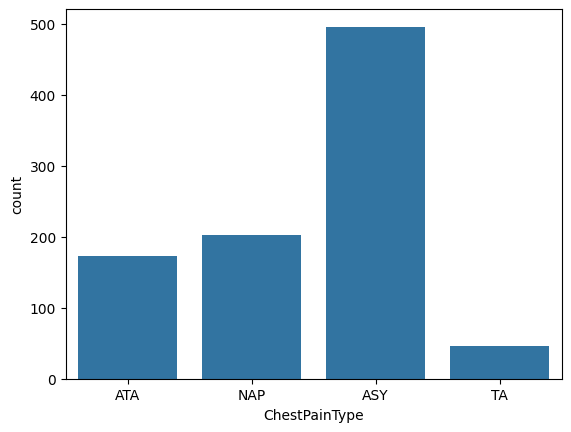

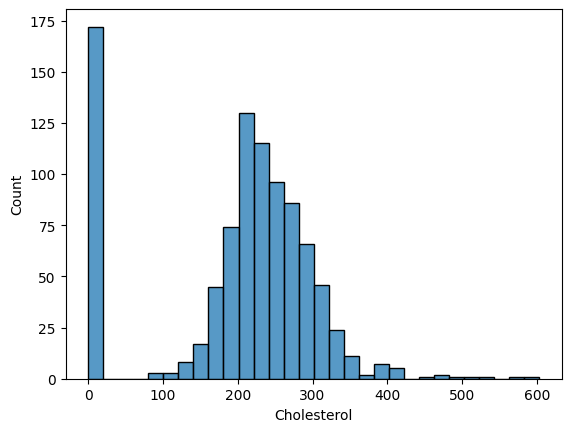

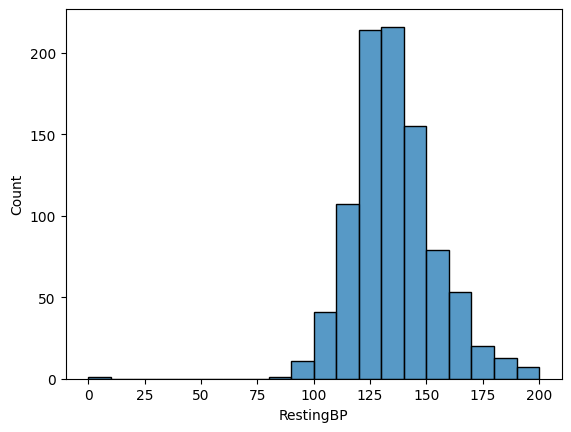

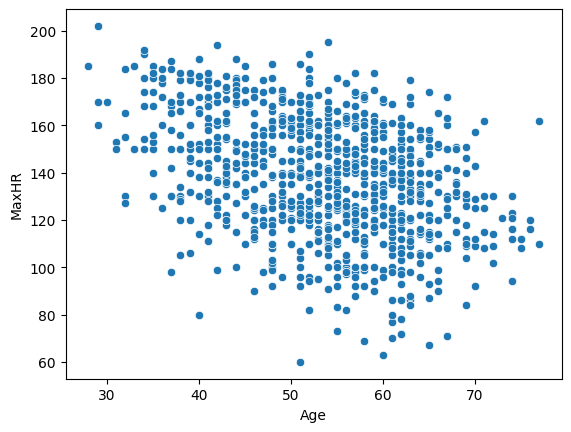

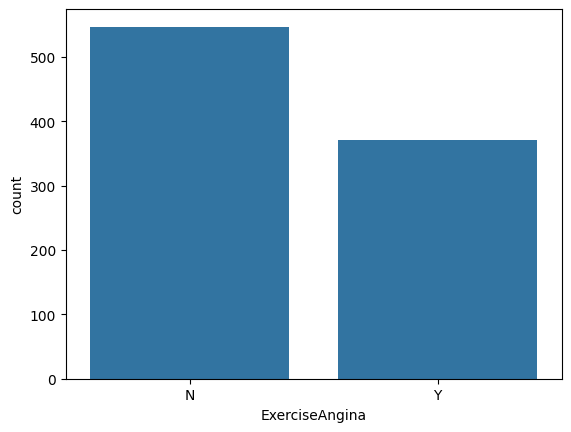

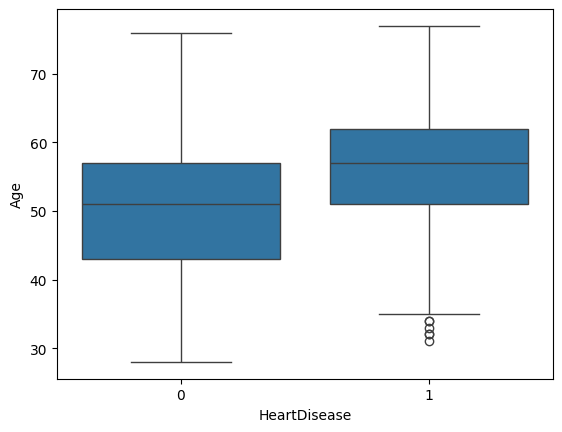

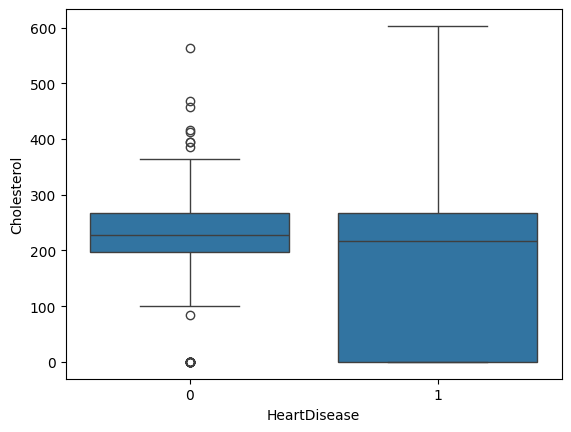

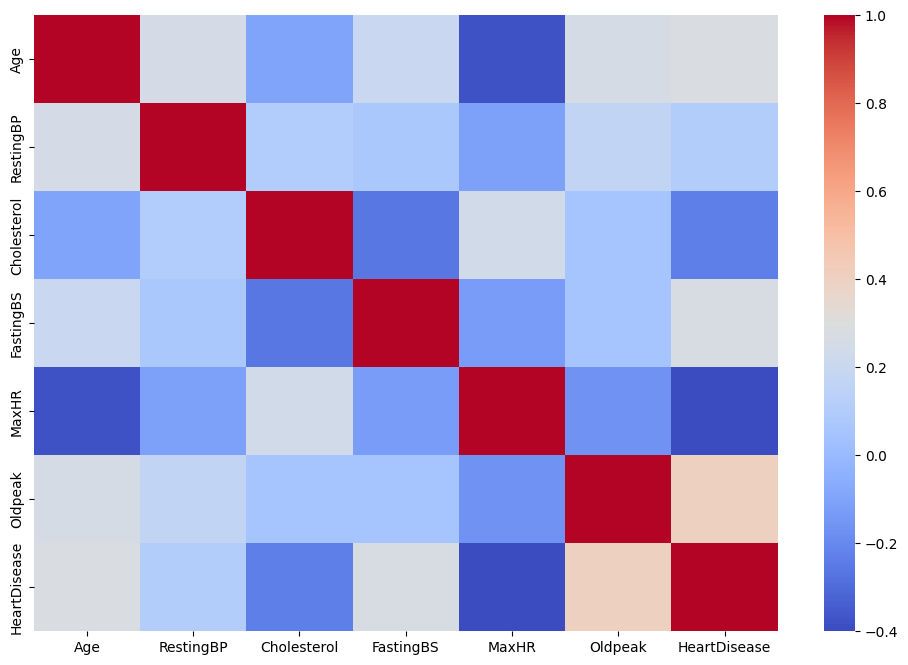

In [ ]:
# =========================================
# LOAD LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================
# LOAD HEART DATASET
# =========================================

heart = pd.read_csv(
    "data/raw folder/heart.csv"
)


# =========================================
# FIRST LOOK
# =========================================

heart.head()

heart.info()

heart.shape


# =========================================
# NULL VALUES CHECK
# =========================================

heart.isnull().sum()


# =========================================
# DUPLICATE CHECK
# =========================================

heart.duplicated().sum()


# =========================================
# REMOVE DUPLICATES
# =========================================

heart.drop_duplicates(inplace=True)


# =========================================
# COLUMN NAMES
# =========================================

heart.columns


# =========================================
# BASIC STATISTICS
# =========================================

heart.describe()


# =========================================
# HEART DISEASE ANALYSIS
# =========================================

heart['HeartDisease'].value_counts()

sns.countplot(
    x='HeartDisease',
    data=heart
)

plt.show()


# =========================================
# AGE ANALYSIS
# =========================================

sns.histplot(
    heart['Age'],
    bins=20
)

plt.show()


# =========================================
# GENDER ANALYSIS
# =========================================

sns.countplot(
    x='Sex',
    data=heart
)

plt.show()


# =========================================
# CHEST PAIN ANALYSIS
# =========================================

sns.countplot(
    x='ChestPainType',
    data=heart
)

plt.show()


# =========================================
# CHOLESTEROL ANALYSIS
# =========================================

sns.histplot(
    heart['Cholesterol'],
    bins=30
)

plt.show()


# =========================================
# BLOOD PRESSURE ANALYSIS
# =========================================

sns.histplot(
    heart['RestingBP'],
    bins=20
)

plt.show()


# =========================================
# MAX HEART RATE ANALYSIS
# =========================================

sns.scatterplot(
    x='Age',
    y='MaxHR',
    data=heart
)

plt.show()


# =========================================
# EXERCISE ANGINA ANALYSIS
# =========================================

sns.countplot(
    x='ExerciseAngina',
    data=heart
)

plt.show()


# =========================================
# HEART DISEASE VS AGE
# =========================================

sns.boxplot(
    x='HeartDisease',
    y='Age',
    data=heart
)

plt.show()


# =========================================
# HEART DISEASE VS CHOLESTEROL
# =========================================

sns.boxplot(
    x='HeartDisease',
    y='Cholesterol',
    data=heart
)

plt.show()


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    heart.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()


# =========================================
# SAVE CLEANED DATASET
# =========================================

heart.to_csv(
    "data/cleaned folder/cleaned_heart.csv",
    index=False
)